# Autonomous Driving Sensor Data Analysis

## 1. Project / Analysis Overview

This analysis investigates the characteristics and performance of RADAR and LiDAR sensors using the truckScenes dataset. The main objective is to compare how much useful sensor evidence each sensor provides for labelled objects under different object and environmental conditions.

The analysis is performed at the object level, where each row in the analysis dataset represents one labelled object observed in one sample. This allows RADAR and LiDAR measurements to be compared consistently across multiple factors.

The main analysis dimensions are:

- Object range / distance
- Object size
- Object motion state
- Object type
- Visibility
- Weather conditions
- Scene / area conditions
- Velocity information

The primary sensor measurements used throughout the analysis are the number of LiDAR and RADAR points associated with each labelled object, together with additional derived metrics where appropriate.

The analysis aims to identify the strengths, limitations, and complementary characteristics of RADAR and LiDAR, and to provide evidence that can support later recommendations for autonomous-driving perception systems.

## 2. Dataset Setup

### 2.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from truckscenes.utils.data_classes import RadarPointCloud
from truckscenes.utils.geometry_utils import points_in_box
from tqdm.auto import tqdm

from truckscenes import TruckScenes

e:\Boeing-RADAR-Autonomous-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Paths

In [2]:
DATA_ROOT = Path("data") / "man-truckscenes"

print(f"Dataset path: {DATA_ROOT.resolve()}")

Dataset path: E:\Boeing-RADAR-Autonomous-\data\man-truckscenes


### 2.3 Load truckScenes

In [3]:
trucksc = TruckScenes(
    dataroot=DATA_ROOT
)

Auto-detected latest version: v1.2-mini
Loading truckscenes tables for version v1.2-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
10 weather_annotation,
Done loading in 1.054 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


e:\Boeing-RADAR-Autonomous-\.venv\Lib\site-packages\truckscenes\truckscenes.py:100: UserWarning: The visualization dependencies are not installed on your system! Run 'pip install "truckscenes-devkit[all]"'.
  warnings.warn('''The visualization dependencies are not installed on your system! '''


## 3. Metadata Inspection

### 3.1 Categories

The category table defines the taxonomy of labelled objects in truckScenes. Each category has a unique token, a category name, and a description. These categories will later be used to compare RADAR and LiDAR evidence across different object types.

In [4]:
category_df = pd.DataFrame(trucksc.category)

category_df[["index", "name", "description"]]

,index,name,description
0,1,vehicle.car,"Vehicle designed primarily for personal use, e..."
1,2,vehicle.truck,Vehicles primarily designed to haul cargo incl...
2,3,vehicle.bus.bendy,Buses and shuttles designed to carry more than...
3,4,vehicle.bus.rigid,Rigid buses and shuttles designed to carry mor...
4,5,vehicle.construction,Vehicles primarily designed for construction. ...
5,6,vehicle.motorcycle,Gasoline or electric powered 2-wheeled vehicle...
6,7,static_object.bicycle_rack,Area or device intended to park or secure the ...
7,8,vehicle.bicycle,Human or electric powered 2-wheeled vehicle de...
8,9,vehicle.trailer,"Any vehicle trailer, both for trucks, cars and..."
9,10,vehicle.emergency.police,All types of police vehicles including police ...


### 3.2 Attributes

The attribute table describes the state or behaviour of labelled objects, such as whether a vehicle is parked, stopped, or moving. These attributes will later be used to derive object motion states.

In [8]:
attribute_df = pd.DataFrame(trucksc.attribute)

attribute_df[["name", "description"]]

,name,description
0,vehicle.parked,Vehicle is stationary (usually for longer dura...
1,vehicle.stopped,"Vehicle, with a driver/rider in/on it, is curr..."
2,vehicle.moving,Vehicle is moving.
3,cycle.with_rider,There is a rider on the bicycle or motorcycle.
4,cycle.without_rider,There is NO rider on the bicycle or motorcycle.
5,pedestrian.sitting_lying_down,The human is sitting or lying down.
6,pedestrian.standing,The human is standing.
7,pedestrian.moving,The human is moving.
8,traffic_sign.pole_mounted,"When the traffic sign is mounted on a pole, ty..."
9,traffic_sign.overhanging,When the traffic sign is mounted above the roa...


### 3.3 Visibility

The visibility table describes how much of an annotated object is visible in the panoramic camera view. Four visibility levels are provided, ranging from heavily occluded objects to almost fully visible objects.

In [5]:
visibility_df = pd.DataFrame(trucksc.visibility)

visibility_df[["level", "description"]]

,level,description
0,1,The object is 0% to 40% visible in panoramic v...
1,2,The object is 41% to 60% visible in panoramic ...
2,3,The object is 61% to 80% visible in panoramic ...
3,4,The object is 81% to 100% visible in panoramic...


### 3.4 Weather

truckScenes v1.2-mini includes a weather annotation for each scene. The weather annotation table contains quantitative environmental measurements including wind speed, wind direction, precipitation, and temperature.

In [6]:
weather_df = pd.DataFrame(trucksc.weather_annotation)

weather_df

,token,wind_speed,wind_direction,precipitation,temperature
0,a6441b377a47495d9d4bf36672d07888,0.14,263.0,0.00,285.6
1,d47c055365f84fe89791c6f0f8785567,0.10,231.0,0.00,282.2
2,e786298a068d413daf281099e7c3c976,0.96,266.0,0.00,286.7
3,2c83a1319b4e49d39ce294a1716bc1bc,1.53,217.0,4.27,281.9
4,fdbd1c1af1e34a25a0ade23929c0ce97,1.70,177.0,0.00,295.5
5,ab6933327238471e83c5cec20a3e2eaa,4.80,264.0,0.00,281.4
6,54a0691884e74da68608489ec8964b4a,2.43,200.0,0.04,285.5
7,e8cf3bd9c9d04dbaa45ea3ec109a075a,0.53,285.0,0.00,282.8
8,93d8caa1dbd2408386212916f67e24fe,0.46,358.0,1.59,273.6
9,06ea480f54bf4353b51857649e27bfaa,0.83,210.0,0.00,289.7


### 3.5 Scene Conditions

Each scene includes a description containing several environmental and driving-context labels. These include weather, area type, time of day, season, lighting, road structure, and construction conditions.

The scene table also links each scene to its corresponding quantitative weather annotation.

In [7]:
scene_df = pd.DataFrame(trucksc.scene)

scene_df[
    [
        "name",
        "description",
        "nbr_samples",
        "weather_annotation_token"
    ]
]

,name,description,nbr_samples,weather_annotation_token
0,scene-0044384af3d8494e913fb8b14915239e-3,weather.clear;area.terminal;daytime.noon;seaso...,40,fdbd1c1af1e34a25a0ade23929c0ce97
1,scene-13f4b71b1bd04a9e88747ad8f58a3f67-4,weather.clear;area.highway;daytime.evening;sea...,40,06ea480f54bf4353b51857649e27bfaa
2,scene-23160c4bff134cdd86b96ee822b4aca9-14,weather.overcast;area.city;daytime.noon;season...,40,ab6933327238471e83c5cec20a3e2eaa
3,scene-3195e3bfd1de4f9ba82f874790c7856c-15,weather.overcast;area.highway;daytime.noon;sea...,40,a6441b377a47495d9d4bf36672d07888
4,scene-3f542f89ec5241b6a4e30ca743adcf34-29,weather.overcast;area.highway;daytime.morning;...,40,e786298a068d413daf281099e7c3c976
5,scene-6be74229febb4aad9e7ae1a37217b231-4,weather.rain;area.terminal;daytime.morning;sea...,40,54a0691884e74da68608489ec8964b4a
6,scene-a6a87db5125846bda72ccfc9931ee153-11,weather.clear;area.city;daytime.noon;season.wi...,40,d47c055365f84fe89791c6f0f8785567
7,scene-b13542304b244af585a646082c57a079-1,weather.snow;area.city;daytime.noon;season.aut...,40,93d8caa1dbd2408386212916f67e24fe
8,scene-b201f6e737e34c2d87830fc1e2911516-6,weather.rain;area.highway;daytime.noon;season....,40,2c83a1319b4e49d39ce294a1716bc1bc
9,scene-fb64d203d417452f830ca73efed80c41-11,weather.clear;area.city;daytime.noon;season.wi...,40,e8cf3bd9c9d04dbaa45ea3ec109a075a


## 4. Master Analysis DataFrame

### 4.1 DataFrame Design

A single master DataFrame is constructed so that all later analyses use the same underlying data structure.

**Granularity:** one row represents one `sample_annotation`, meaning one labelled object observed in one sample/keyframe.

This granularity allows object-level properties, sensor evidence, and scene-level environmental conditions to be analysed together consistently.

| Group | Planned variables |
|---|---|
| Identification | `scene_token`, `sample_token`, `annotation_token`, `instance_token`, `timestamp` |
| Object information | `category`, `attribute`, `motion_state` |
| Object size | `size_1`, `size_2`, `size_3`, `object_volume` |
| Visibility | `visibility_token`, `visibility_level` |
| Position | `object_x`, `object_y`, `object_z`, `ego_x`, `ego_y`, `ego_z` |
| Range | `distance_2d`, `distance_3d` |
| Sensor evidence | `num_lidar_pts`, `num_radar_pts`, `lidar_detected`, `radar_detected` |
| Scene conditions | `weather`, `area`, `daytime`, `season`, `lighting`, `structure`, `construction` |
| Weather measurements | `wind_speed`, `wind_direction`, `precipitation`, `temperature` |

Additional velocity-related variables may be added later once their extraction and interpretation are validated.

### 4.2 Data Extraction

The master dataset is constructed from the `sample_annotation` table. Each annotation is linked to its corresponding sample, scene, ego pose, visibility record, object attribute, and weather annotation.

At this stage, the required raw and lookup variables are extracted into a single object-level DataFrame. Derived variables are created separately in Section 4.3.

In [8]:
# Lookup dictionaries for faster access
sample_lookup = {x["token"]: x for x in trucksc.sample}
scene_lookup = {x["token"]: x for x in trucksc.scene}
visibility_lookup = {x["token"]: x for x in trucksc.visibility}
attribute_lookup = {x["token"]: x for x in trucksc.attribute}
ego_pose_lookup = {x["token"]: x for x in trucksc.ego_pose}
weather_lookup = {x["token"]: x for x in trucksc.weather_annotation}

rows = []

for ann in trucksc.sample_annotation:

    # Related sample
    sample = sample_lookup[ann["sample_token"]]

    # Related scene
    scene = scene_lookup[sample["scene_token"]]

    # Ego pose at the sample timestamp
    ego_pose = ego_pose_lookup[sample["ego_pose_token"]]

    # Visibility
    visibility = visibility_lookup[ann["visibility_token"]]

    # Object attribute
    if ann["attribute_tokens"]:
        attribute_names = [
            attribute_lookup[token]["name"]
            for token in ann["attribute_tokens"]
        ]
        attribute = "; ".join(attribute_names)
    else:
        attribute = None

    # Weather annotation linked to the scene
    weather_token = scene.get("weather_annotation_token")

    if weather_token:
        weather = weather_lookup[weather_token]
    else:
        weather = {}

    rows.append({
        # Identification
        "scene_token": scene["token"],
        "sample_token": sample["token"],
        "annotation_token": ann["token"],
        "instance_token": ann["instance_token"],
        "timestamp": sample["timestamp"],

        # Object information
        "category": ann["category_name"],
        "attribute": attribute,

        # Visibility
        "visibility_token": ann["visibility_token"],
        "visibility_level": visibility["level"],
        "visibility_description": visibility["description"],

        # Object size
        "size_1": ann["size"][0],
        "size_2": ann["size"][1],
        "size_3": ann["size"][2],

        # Object position
        "object_x": ann["translation"][0],
        "object_y": ann["translation"][1],
        "object_z": ann["translation"][2],

        # Ego position
        "ego_x": ego_pose["translation"][0],
        "ego_y": ego_pose["translation"][1],
        "ego_z": ego_pose["translation"][2],

        # Sensor evidence
        "num_lidar_pts": ann["num_lidar_pts"],
        "num_radar_pts": ann["num_radar_pts"],

        # Raw scene metadata
        "scene_name": scene["name"],
        "scene_description": scene["description"],

        # Quantitative weather measurements
        "weather_annotation_token": weather_token,
        "wind_speed": weather.get("wind_speed"),
        "wind_direction": weather.get("wind_direction"),
        "precipitation": weather.get("precipitation"),
        "temperature": weather.get("temperature"),
    })

df = pd.DataFrame(rows)
column_order = [
    # Tokens / identifiers
    "scene_token","sample_token","annotation_token","instance_token","visibility_token","weather_annotation_token",
    # Time
    "timestamp",
    # Object information
    "category","attribute",
    # Visibility
    "visibility_level","visibility_description",
    # Object size
    "size_1","size_2","size_3",
    # Object position
    "object_x","object_y","object_z",
    # Ego position
    "ego_x","ego_y","ego_z",
    # Sensor evidence
    "num_lidar_pts","num_radar_pts",
    # Scene metadata
    "scene_name","scene_description",
    # Weather measurements
    "wind_speed","wind_direction","precipitation","temperature",
]
df = df[column_order]

df.head()

,scene_token,sample_token,annotation_token,instance_token,visibility_token,weather_annotation_token,timestamp,category,attribute,visibility_level,...,ego_y,ego_z,num_lidar_pts,num_radar_pts,scene_name,scene_description,wind_speed,wind_direction,precipitation,temperature
0,044c648ac12345f1aedf33c9f91cdc5a,32d2bcf46e734dffb14fe2e0a823d059,50873dd5195b47bc9544ac2821e054e0,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473372698161,vehicle.car,vehicle.parked,4,...,5.367848e+06,593.99,430,2,scene-0044384af3d8494e913fb8b14915239e-3,weather.clear;area.terminal;daytime.noon;seaso...,1.7,177.0,0.0,295.5
1,044c648ac12345f1aedf33c9f91cdc5a,deb7b3f332f042d49e7636d6e4959354,9f0e8f997dc647bf9a0a20c679b1804d,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473373198647,vehicle.car,vehicle.parked,4,...,5.367849e+06,593.98,567,3,scene-0044384af3d8494e913fb8b14915239e-3,weather.clear;area.terminal;daytime.noon;seaso...,1.7,177.0,0.0,295.5
2,044c648ac12345f1aedf33c9f91cdc5a,a574551be31547e4b7c78ff87c75abb3,2c8422f4ac674f949fa1124dcaa1fa5e,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473373698280,vehicle.car,vehicle.parked,4,...,5.367850e+06,593.99,765,1,scene-0044384af3d8494e913fb8b14915239e-3,weather.clear;area.terminal;daytime.noon;seaso...,1.7,177.0,0.0,295.5
3,044c648ac12345f1aedf33c9f91cdc5a,1393759bf6ff4f8e88deff0da0dc2aca,c4d5f41838054ff581106dc5e0ed10c2,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473374197968,vehicle.car,vehicle.parked,4,...,5.367852e+06,594.00,1040,2,scene-0044384af3d8494e913fb8b14915239e-3,weather.clear;area.terminal;daytime.noon;seaso...,1.7,177.0,0.0,295.5
4,044c648ac12345f1aedf33c9f91cdc5a,368662645c194921b716c026347db664,384bb8f773d640bd851c2581d8750294,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473374698243,vehicle.car,vehicle.parked,4,...,5.367854e+06,594.02,1418,6,scene-0044384af3d8494e913fb8b14915239e-3,weather.clear;area.terminal;daytime.noon;seaso...,1.7,177.0,0.0,295.5


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25750 entries, 0 to 25749
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   scene_token               25750 non-null  str    
 1   sample_token              25750 non-null  str    
 2   annotation_token          25750 non-null  str    
 3   instance_token            25750 non-null  str    
 4   visibility_token          25750 non-null  str    
 5   weather_annotation_token  25750 non-null  str    
 6   timestamp                 25750 non-null  int64  
 7   category                  25750 non-null  str    
 8   attribute                 24612 non-null  str    
 9   visibility_level          25750 non-null  int64  
 10  visibility_description    25750 non-null  str    
 11  size_1                    25750 non-null  float64
 12  size_2                    25750 non-null  float64
 13  size_3                    25750 non-null  float64
 14  object_x         

### 4.3 Derived Variables

Several analysis-ready variables are derived from the extracted metadata. These include object volume, distance from the ego vehicle, sensor detection indicators, object motion state, and individual scene-condition variables parsed from the scene description.

In [10]:
# 1. Object size
df["object_volume"] = (
    df["size_1"]
    * df["size_2"]
    * df["size_3"]
)

# 2. Distance from ego vehicle
dx = df["object_x"] - df["ego_x"]
dy = df["object_y"] - df["ego_y"]
dz = df["object_z"] - df["ego_z"]

df["distance_2d"] = np.sqrt(dx**2 + dy**2)

df["distance_3d"] = np.sqrt(
    dx**2 + dy**2 + dz**2
)

# 3. Sensor detection indicators
df["lidar_detected"] = df["num_lidar_pts"] > 0
df["radar_detected"] = df["num_radar_pts"] > 0

# 4. Object motion state
def derive_motion_state(attribute):
    if pd.isna(attribute):
        return "unknown"

    attributes = attribute.split("; ")

    if any(attr in [
        "vehicle.moving",
        "pedestrian.moving"
    ] for attr in attributes):
        return "moving"

    if any(attr in [
        "vehicle.parked",
        "vehicle.stopped",
        "pedestrian.standing",
        "pedestrian.sitting_lying_down"
    ] for attr in attributes):
        return "stationary"

    return "unknown"
df["motion_state"] = df["attribute"].apply(derive_motion_state)

# 5. Scene conditions
def parse_scene_description(description):
    conditions = {}

    for item in description.split(";"):
        if "." in item:
            key, value = item.split(".", 1)
            conditions[key] = value

    return conditions

scene_conditions = df["scene_description"].apply(parse_scene_description)

for condition in [
    "weather",
    "area",
    "daytime",
    "season",
    "lighting",
    "structure",
    "construction"
]:
    df[condition] = scene_conditions.apply(
        lambda x: x.get(condition)
    )

### 4.4 DataFrame Summary

The completed master DataFrame is summarized to confirm its structure and provide an overview of the available object, sensor, and environmental variables before analysis.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25750 entries, 0 to 25749
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   scene_token               25750 non-null  str    
 1   sample_token              25750 non-null  str    
 2   annotation_token          25750 non-null  str    
 3   instance_token            25750 non-null  str    
 4   visibility_token          25750 non-null  str    
 5   weather_annotation_token  25750 non-null  str    
 6   timestamp                 25750 non-null  int64  
 7   category                  25750 non-null  str    
 8   attribute                 24612 non-null  str    
 9   visibility_level          25750 non-null  int64  
 10  visibility_description    25750 non-null  str    
 11  size_1                    25750 non-null  float64
 12  size_2                    25750 non-null  float64
 13  size_3                    25750 non-null  float64
 14  object_x         

In [25]:
df.head()

,scene_token,sample_token,annotation_token,instance_token,visibility_token,weather_annotation_token,timestamp,category,attribute,visibility_level,...,lidar_detected,radar_detected,motion_state,weather,area,daytime,season,lighting,structure,construction
0,044c648ac12345f1aedf33c9f91cdc5a,32d2bcf46e734dffb14fe2e0a823d059,50873dd5195b47bc9544ac2821e054e0,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473372698161,vehicle.car,vehicle.parked,4,...,True,True,stationary,clear,terminal,noon,autumn,illuminated,regular,unchanged
1,044c648ac12345f1aedf33c9f91cdc5a,deb7b3f332f042d49e7636d6e4959354,9f0e8f997dc647bf9a0a20c679b1804d,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473373198647,vehicle.car,vehicle.parked,4,...,True,True,stationary,clear,terminal,noon,autumn,illuminated,regular,unchanged
2,044c648ac12345f1aedf33c9f91cdc5a,a574551be31547e4b7c78ff87c75abb3,2c8422f4ac674f949fa1124dcaa1fa5e,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473373698280,vehicle.car,vehicle.parked,4,...,True,True,stationary,clear,terminal,noon,autumn,illuminated,regular,unchanged
3,044c648ac12345f1aedf33c9f91cdc5a,1393759bf6ff4f8e88deff0da0dc2aca,c4d5f41838054ff581106dc5e0ed10c2,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473374197968,vehicle.car,vehicle.parked,4,...,True,True,stationary,clear,terminal,noon,autumn,illuminated,regular,unchanged
4,044c648ac12345f1aedf33c9f91cdc5a,368662645c194921b716c026347db664,384bb8f773d640bd851c2581d8750294,163b7c695f7243779ef5e5f0fd844063,6adc1826065b452195ae6a76317b8ab5,fdbd1c1af1e34a25a0ade23929c0ce97,1695473374698243,vehicle.car,vehicle.parked,4,...,True,True,stationary,clear,terminal,noon,autumn,illuminated,regular,unchanged


In [12]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique scenes: {df['scene_token'].nunique()}")
print(f"Unique samples: {df['sample_token'].nunique()}")
print(f"Unique objects: {df['instance_token'].nunique()}")
print(f"Unique annotations: {df['annotation_token'].nunique()}")

Rows: 25,750
Columns: 41
Unique scenes: 10
Unique samples: 400
Unique objects: 1094
Unique annotations: 25750


## 5. Quantitative Analysis

### 5.1 Range / Distance

**Research question:** How does object distance from the ego vehicle affect the amount of RADAR and LiDAR evidence available for labelled objects?

The analysis uses `distance_3d` as the object range measure. Sensor evidence is examined using both point counts and detection indicators. Point counts describe how much sensor information is associated with an object, while detection indicators show whether the sensor provides at least one return.

In [13]:
df["distance_3d"].describe()

count    25750.000000
mean        73.076052
std         49.455592
min          2.754293
25%         34.955448
50%         61.321268
75%        103.266494
max        229.424608
Name: distance_3d, dtype: float64

In [14]:
df["distance_3d"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25     34.955448
0.50     61.321268
0.75    103.266494
0.90    146.571115
0.95    173.668370
0.99    207.846836
Name: distance_3d, dtype: float64

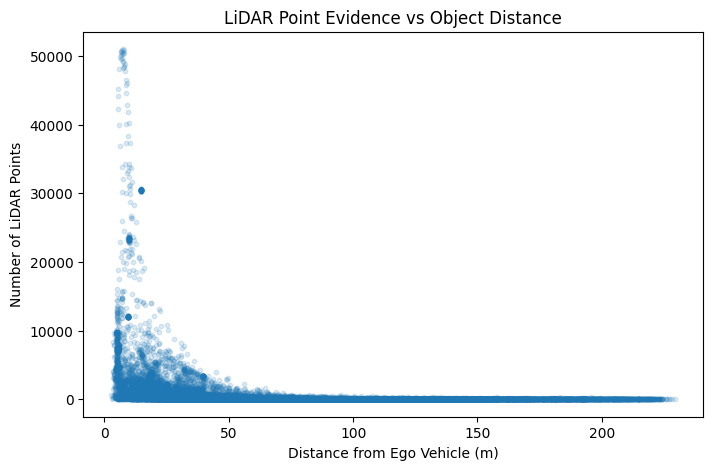

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_3d"],
    df["num_lidar_pts"],
    alpha=0.15,
    s=10
)

plt.xlabel("Distance from Ego Vehicle (m)")
plt.ylabel("Number of LiDAR Points")
plt.title("LiDAR Point Evidence vs Object Distance")

plt.show()

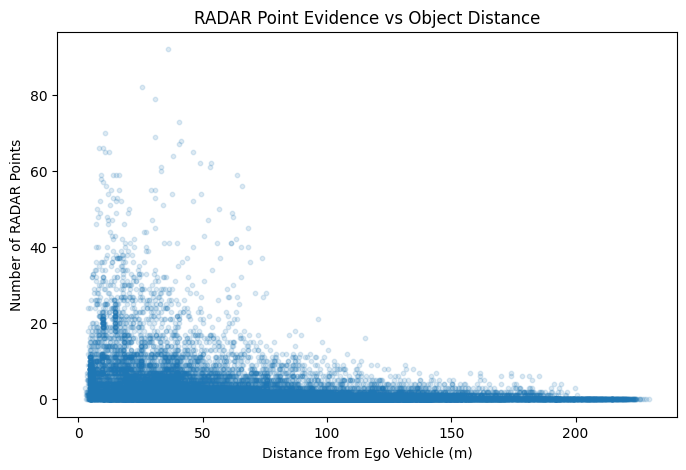

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_3d"],
    df["num_radar_pts"],
    alpha=0.15,
    s=10
)

plt.xlabel("Distance from Ego Vehicle (m)")
plt.ylabel("Number of RADAR Points")
plt.title("RADAR Point Evidence vs Object Distance")

plt.show()

In [17]:
distance_bins = np.arange(0, 251, 25)

df["distance_band"] = pd.cut(
    df["distance_3d"],
    bins=distance_bins,
    right=False
)

df["distance_band"].value_counts().sort_index()

distance_band
[0, 25)       4009
[25, 50)      6443
[50, 75)      4948
[75, 100)     3544
[100, 125)    2644
[125, 150)    1784
[150, 175)    1133
[175, 200)     807
[200, 225)     431
[225, 250)       7
Name: count, dtype: int64

In [18]:
distance_summary = (
    df.groupby("distance_band", observed=True)
    .agg(
        n_objects=("annotation_token", "count"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        lidar_detection_rate=("lidar_detected", "mean"),
        radar_detection_rate=("radar_detected", "mean")
    )
    .reset_index()
)



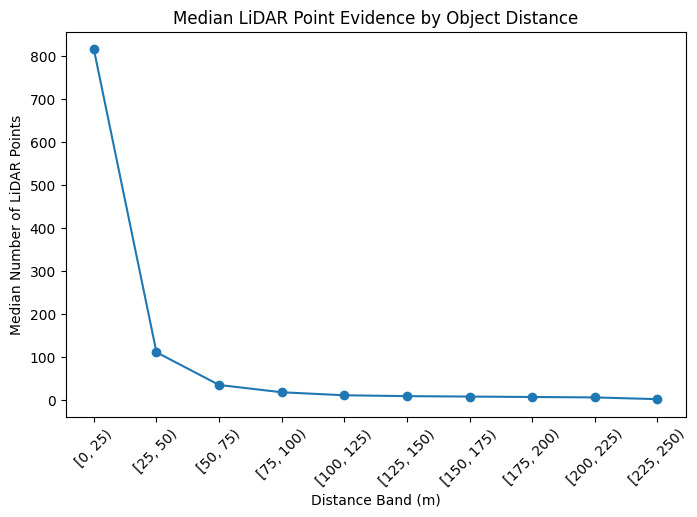

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    distance_summary["distance_band"].astype(str),
    distance_summary["median_lidar_pts"],
    marker="o"
)

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of LiDAR Points")
plt.title("Median LiDAR Point Evidence by Object Distance")
plt.xticks(rotation=45)

plt.show()

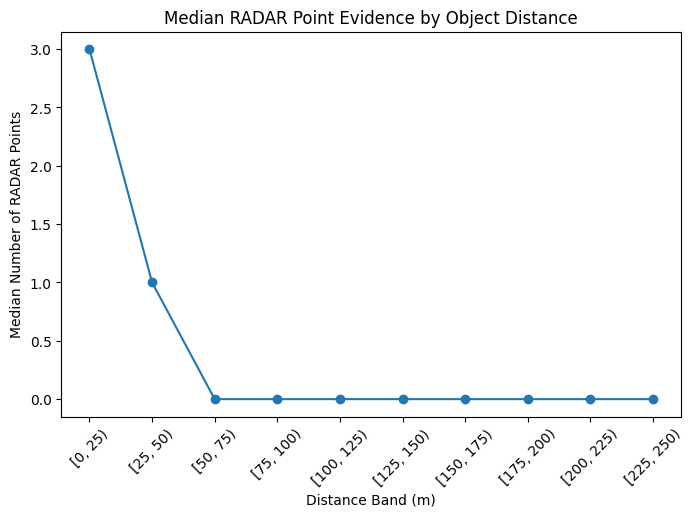

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    distance_summary["distance_band"].astype(str),
    distance_summary["median_radar_pts"],
    marker="o"
)

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of RADAR Points")
plt.title("Median RADAR Point Evidence by Object Distance")
plt.xticks(rotation=45)

plt.show()

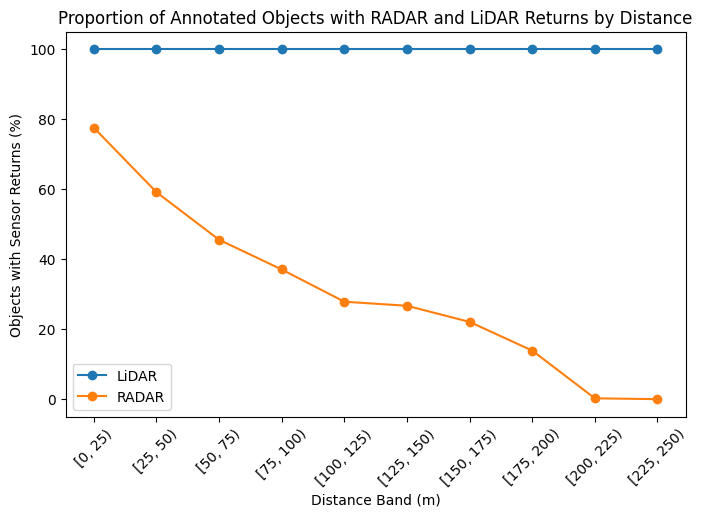

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    distance_summary["distance_band"].astype(str),
    distance_summary["lidar_detection_rate"] * 100,
    marker="o",
    label="LiDAR"
)

plt.plot(
    distance_summary["distance_band"].astype(str),
    distance_summary["radar_detection_rate"] * 100,
    marker="o",
    label="RADAR"
)

plt.xlabel("Distance Band (m)")
plt.ylabel("Objects with Sensor Returns (%)")
plt.title("Proportion of Annotated Objects with RADAR and LiDAR Returns by Distance")
plt.xticks(rotation=45)
plt.legend()

plt.show()

#### RADAR Point Evidence Among Detected Objects

Because the median RADAR point count becomes zero at longer distances, an additional analysis is performed using only objects that contain at least one RADAR return. This separates the probability of receiving a RADAR return from the amount of RADAR evidence available when a return is present.

In [40]:
radar_detected_df = df[df["radar_detected"]].copy()

radar_detected_summary = (
    radar_detected_df.groupby("distance_band", observed=True)
    .agg(
        n_detected_objects=("annotation_token", "count"),
        median_radar_pts_detected=("num_radar_pts", "median"),
        mean_radar_pts_detected=("num_radar_pts", "mean")
    )
    .reset_index()
)

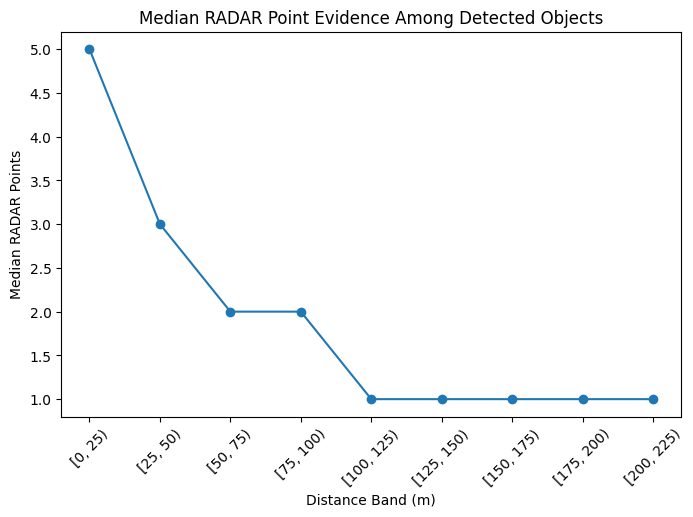

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    radar_detected_summary["distance_band"].astype(str),
    radar_detected_summary["median_radar_pts_detected"],
    marker="o"
)

plt.xlabel("Distance Band (m)")
plt.ylabel("Median RADAR Points")
plt.title("Median RADAR Point Evidence Among Detected Objects")
plt.xticks(rotation=45)

plt.show()

#### Findings

Both sensors show a strong reduction in object-associated point evidence as distance increases. LiDAR point density decreases sharply, with the median falling from 815 points within 25 m to 110 points at 25–50 m, and continuing to decline at longer ranges.

RADAR measurements are much sparser. The overall median RADAR point count decreases from 3 points within 25 m to 1 point at 25–50 m, and becomes 0 beyond 50 m because more than half of the labelled objects in those distance bands contain no associated RADAR returns.

When considering only objects that contain at least one RADAR return, the amount of RADAR evidence also decreases with distance. The median falls from 5 points within 25 m to 3 points at 25–50 m, 2 points at 50–100 m, and approximately 1 point beyond 100 m.

The proportion of labelled objects with RADAR returns decreases steadily with range, from about 78% within 25 m to 59% at 25–50 m, 46% at 50–75 m, and around 28% at 100–125 m. RADAR returns become relatively uncommon beyond 175 m in this dataset.

These results suggest that range affects RADAR in two ways: fewer objects receive RADAR returns at longer distances, and the objects that are detected typically contain fewer RADAR points. LiDAR also loses point density with range, but continues to provide object-associated points throughout the observed distance range.

### 5.2 Object Size

**Research question:** How does object size affect the amount of RADAR and LiDAR evidence associated with labelled objects?

Object size is represented using bounding-box volume, calculated from the three object dimensions. Because object sizes vary substantially across different object types, both the continuous relationship and grouped size comparisons are examined.

In [42]:
df["object_volume"].describe()

count    25750.000000
mean        28.606248
std         58.096811
min          0.012204
25%          1.391259
50%         11.621403
75%         18.876269
max        848.615701
Name: object_volume, dtype: float64

In [43]:
df["object_volume"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25      1.391259
0.50     11.621403
0.75     18.876269
0.90     89.408880
0.95    139.825055
0.99    241.498442
Name: object_volume, dtype: float64

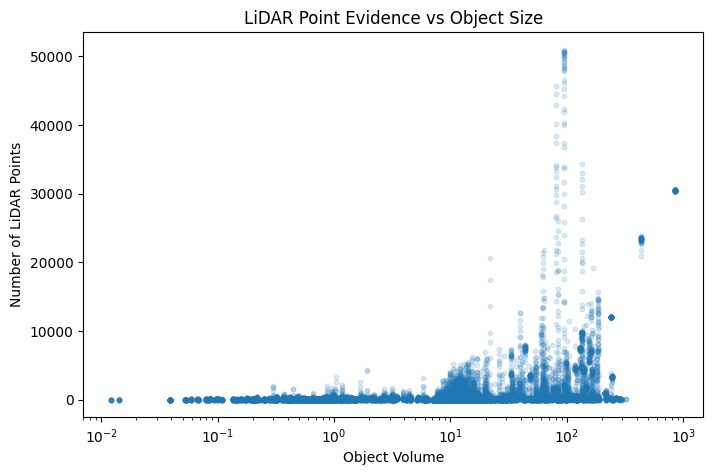

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["object_volume"],
    df["num_lidar_pts"],
    alpha=0.15,
    s=10
)

plt.xscale("log")

plt.xlabel("Object Volume")
plt.ylabel("Number of LiDAR Points")
plt.title("LiDAR Point Evidence vs Object Size")

plt.show()

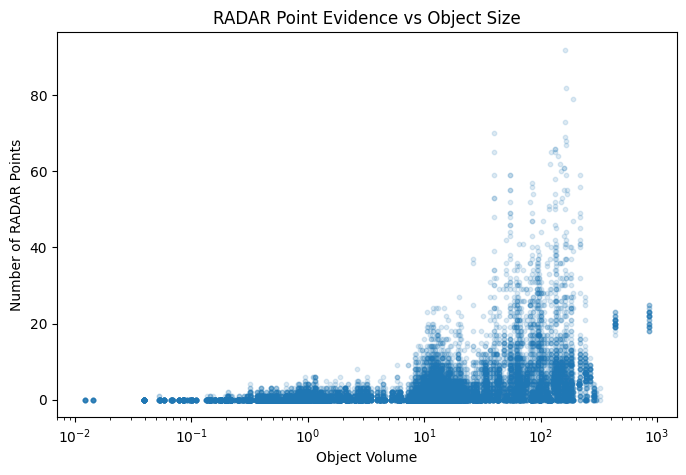

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["object_volume"],
    df["num_radar_pts"],
    alpha=0.15,
    s=10
)

plt.xscale("log")

plt.xlabel("Object Volume")
plt.ylabel("Number of RADAR Points")
plt.title("RADAR Point Evidence vs Object Size")

plt.show()

In [46]:
df["size_group"] = pd.qcut(
    df["object_volume"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

df["size_group"].value_counts().sort_index()

size_group
Small         6440
Medium        6456
Large         6423
Very Large    6431
Name: count, dtype: int64

In [47]:
size_summary = (
    df.groupby("size_group", observed=True)
    .agg(
        n_objects=("annotation_token", "count"),
        median_volume=("object_volume", "median"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        lidar_return_rate=("lidar_detected", "mean"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

size_summary

,size_group,n_objects,median_volume,median_lidar_pts,median_radar_pts,lidar_return_rate,radar_return_rate
0,Small,6440,0.664273,25.0,0.0,1.0,0.159472
1,Medium,6456,8.855429,28.0,0.0,1.0,0.412794
2,Large,6423,13.730609,34.0,1.0,1.0,0.553635
3,Very Large,6431,66.548436,141.0,3.0,1.0,0.748251


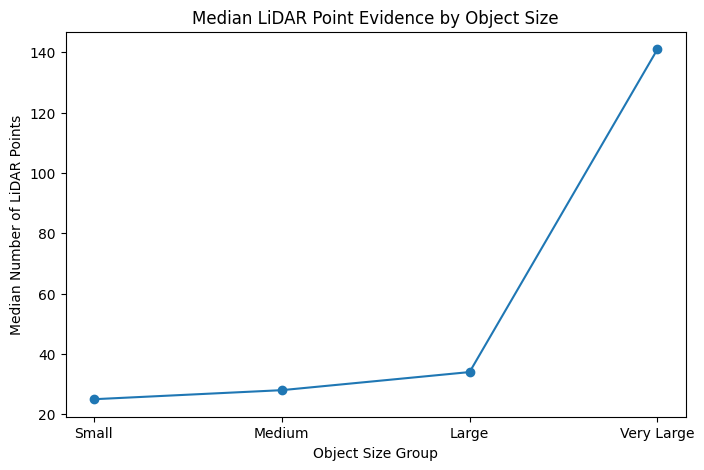

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    size_summary["size_group"].astype(str),
    size_summary["median_lidar_pts"],
    marker="o"
)

plt.xlabel("Object Size Group")
plt.ylabel("Median Number of LiDAR Points")
plt.title("Median LiDAR Point Evidence by Object Size")

plt.show()

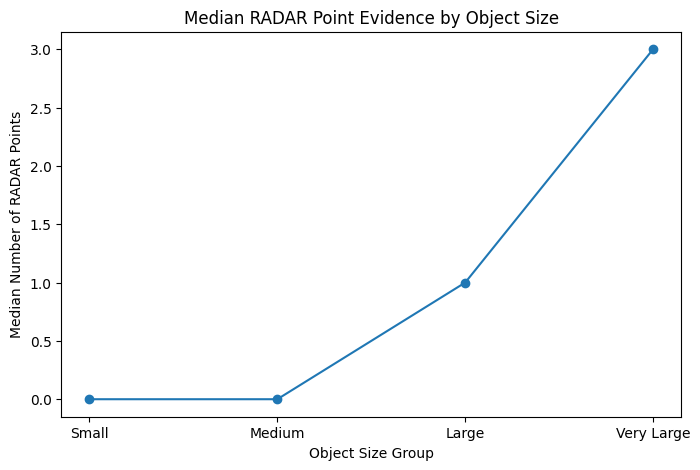

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    size_summary["size_group"].astype(str),
    size_summary["median_radar_pts"],
    marker="o"
)

plt.xlabel("Object Size Group")
plt.ylabel("Median Number of RADAR Points")
plt.title("Median RADAR Point Evidence by Object Size")

plt.show()

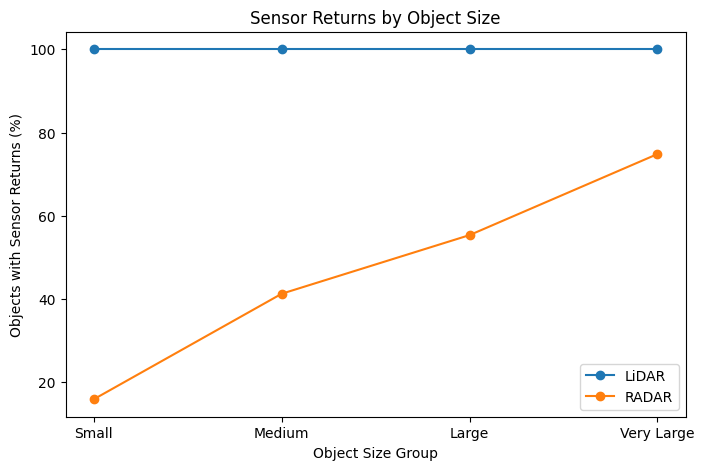

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    size_summary["size_group"].astype(str),
    size_summary["lidar_return_rate"] * 100,
    marker="o",
    label="LiDAR"
)

plt.plot(
    size_summary["size_group"].astype(str),
    size_summary["radar_return_rate"] * 100,
    marker="o",
    label="RADAR"
)

plt.xlabel("Object Size Group")
plt.ylabel("Objects with Sensor Returns (%)")
plt.title("Sensor Returns by Object Size")
plt.legend()

plt.show()

#### Findings

Object size has a clear positive relationship with the amount of sensor evidence associated with labelled objects. Larger objects generally contain more LiDAR and RADAR points than smaller objects.

The grouped analysis shows that median LiDAR point counts increase substantially for the largest objects, while median RADAR point counts also increase from approximately zero for smaller objects to several points for very large objects.

The proportion of annotated objects containing RADAR returns also increases strongly with object size, from around 16% for the smallest group to approximately 75% for the largest group. This suggests that larger objects are more likely to generate measurable RADAR evidence in the dataset.

These results should be interpreted together with later analyses of object type and distance, since larger objects are often different classes of road users and may also appear at different typical ranges.

### 5.3 Object Motion State

**Research question:** Does the amount of RADAR and LiDAR evidence differ between moving and stationary objects?

Motion state is derived from the object attributes provided by truckScenes. Vehicles labelled as `vehicle.moving` and pedestrians labelled as `pedestrian.moving` are classified as moving, while parked/stopped vehicles and standing/sitting pedestrians are classified as stationary.

Objects whose attributes do not explicitly indicate motion, such as bicycles with or without riders and traffic signs, are classified as unknown and excluded from the moving-versus-stationary comparison.

In [52]:
motion_df = df[
    df["motion_state"].isin(["moving", "stationary"])
].copy()

In [53]:
motion_summary = (
    motion_df.groupby("motion_state")
    .agg(
        n_objects=("annotation_token", "count"),
        median_distance=("distance_3d", "median"),
        median_volume=("object_volume", "median"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        lidar_return_rate=("lidar_detected", "mean"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

motion_summary

,motion_state,n_objects,median_distance,median_volume,median_lidar_pts,median_radar_pts,lidar_return_rate,radar_return_rate
0,moving,11304,74.825308,14.146556,35.0,1.0,1.0,0.544232
1,stationary,6401,52.393947,13.263100,58.0,1.0,1.0,0.614748


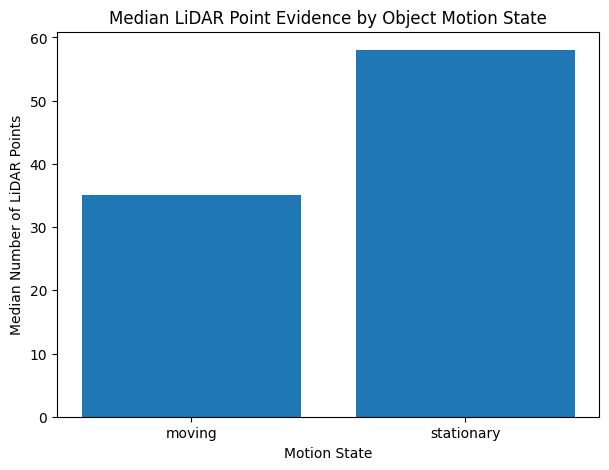

In [54]:
plt.figure(figsize=(7, 5))

plt.bar(
    motion_summary["motion_state"],
    motion_summary["median_lidar_pts"]
)

plt.xlabel("Motion State")
plt.ylabel("Median Number of LiDAR Points")
plt.title("Median LiDAR Point Evidence by Object Motion State")

plt.show()

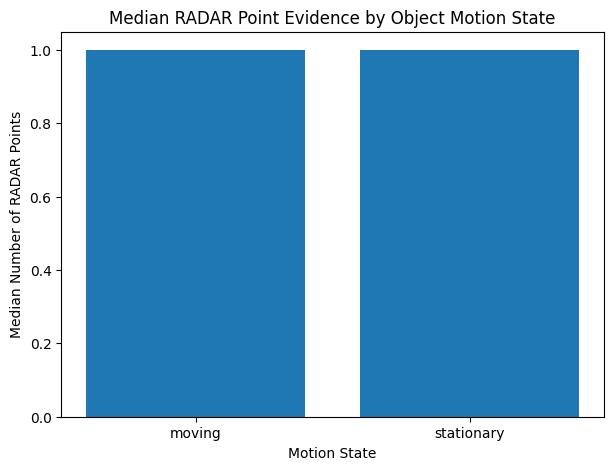

In [55]:
plt.figure(figsize=(7, 5))

plt.bar(
    motion_summary["motion_state"],
    motion_summary["median_radar_pts"]
)

plt.xlabel("Motion State")
plt.ylabel("Median Number of RADAR Points")
plt.title("Median RADAR Point Evidence by Object Motion State")

plt.show()

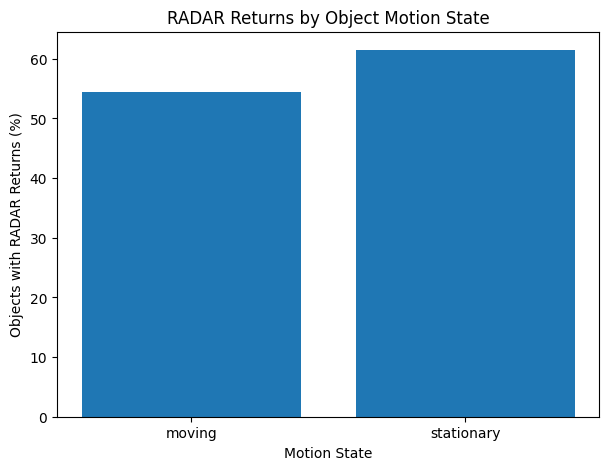

In [56]:
plt.figure(figsize=(7, 5))

plt.bar(
    motion_summary["motion_state"],
    motion_summary["radar_return_rate"] * 100
)

plt.xlabel("Motion State")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Object Motion State")

plt.show()

#### Findings

Moving and stationary objects show the same median RADAR point count of 1 point, suggesting that object motion state alone does not produce a clear difference in RADAR point density in this initial comparison.

Stationary objects contain more LiDAR evidence, with a median of 58 points compared with 35 points for moving objects. They also have a somewhat higher proportion of annotations containing RADAR returns (approximately 61% compared with 54%).

However, the two groups differ substantially in range. Moving objects have a median distance of approximately 75 m, compared with 52 m for stationary objects. Since the previous range analysis showed a strong reduction in sensor evidence with distance, the observed differences cannot be attributed to motion state alone.

Therefore, this analysis does not provide strong evidence that motion state directly affects point density. The primary RADAR advantage for moving objects may instead arise from its velocity-measurement capability, which is investigated separately.

### 5.4 Object Type

**Research question:** How does RADAR and LiDAR evidence differ across different types of labelled objects?

truckScenes contains multiple object categories, including vehicles, pedestrians, bicycles, movable objects, and static objects. Because some categories may contain very few observations, the category distribution is inspected before performing comparisons.

In [57]:
category_counts = (
    df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_objects")
)

category_counts

,category,n_objects
0,vehicle.car,11811
1,static_object.traffic_sign,6666
2,vehicle.truck,2230
3,vehicle.trailer,1468
4,human.pedestrian.adult,1000
5,movable_object.trafficcone,857
6,vehicle.bus.rigid,379
7,vehicle.ego_trailer,360
8,vehicle.train,200
9,human.pedestrian.construction_worker,172


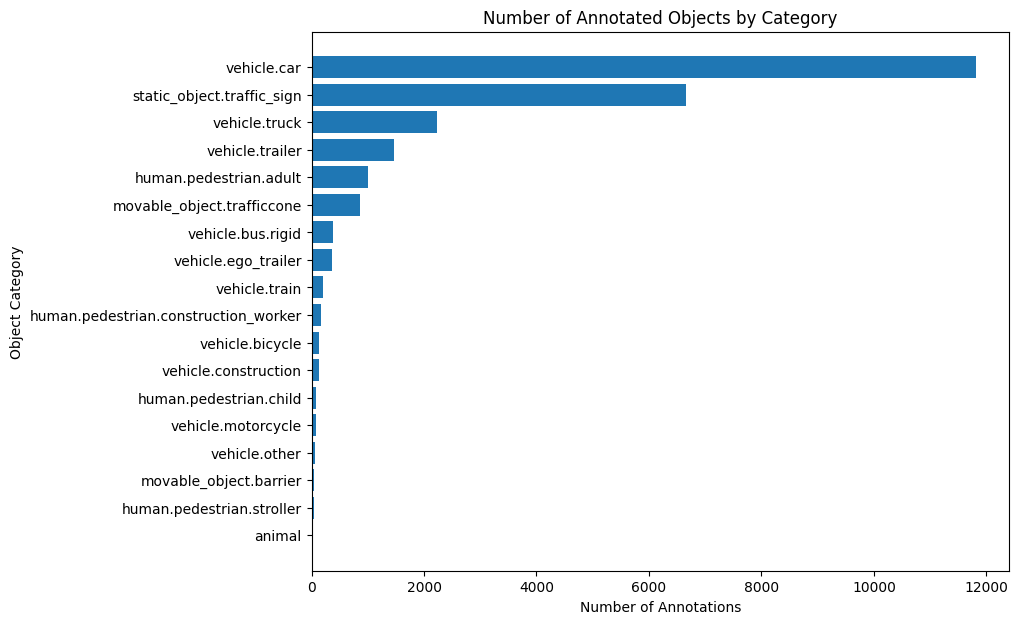

In [58]:
plt.figure(figsize=(9, 7))

plt.barh(
    category_counts["category"],
    category_counts["n_objects"]
)

plt.xlabel("Number of Annotations")
plt.ylabel("Object Category")
plt.title("Number of Annotated Objects by Category")
plt.gca().invert_yaxis()

plt.show()

In [60]:
valid_categories = category_counts.loc[
    category_counts["n_objects"] >= 100,
    "category"
]

object_type_df = df[
    df["category"].isin(valid_categories)
].copy()

In [61]:
object_type_summary = (
    object_type_df.groupby("category")
    .agg(
        n_objects=("annotation_token", "count"),
        median_distance=("distance_3d", "median"),
        median_volume=("object_volume", "median"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
    .sort_values("n_objects", ascending=False)
)

object_type_summary

,category,n_objects,median_distance,median_volume,median_lidar_pts,median_radar_pts,radar_return_rate
6,vehicle.car,11811,72.674513,12.636954,25.0,0.0,0.497841
3,static_object.traffic_sign,6666,54.523003,0.896068,37.0,0.0,0.237024
11,vehicle.truck,2230,68.073619,73.079110,148.5,4.0,0.798655
9,vehicle.trailer,1468,52.615838,99.899524,172.0,5.0,0.796322
0,human.pedestrian.adult,1000,40.659606,0.948140,40.0,0.0,0.385000
2,movable_object.trafficcone,857,87.631630,0.579207,8.0,0.0,0.071179
5,vehicle.bus.rigid,379,50.871612,164.467576,103.0,2.0,0.799472
8,vehicle.ego_trailer,360,5.169477,134.956194,7034.0,6.0,0.933333
10,vehicle.train,200,14.760980,244.389404,12030.5,9.0,1.000000
1,human.pedestrian.construction_worker,172,42.273733,1.144148,55.5,0.0,0.290698


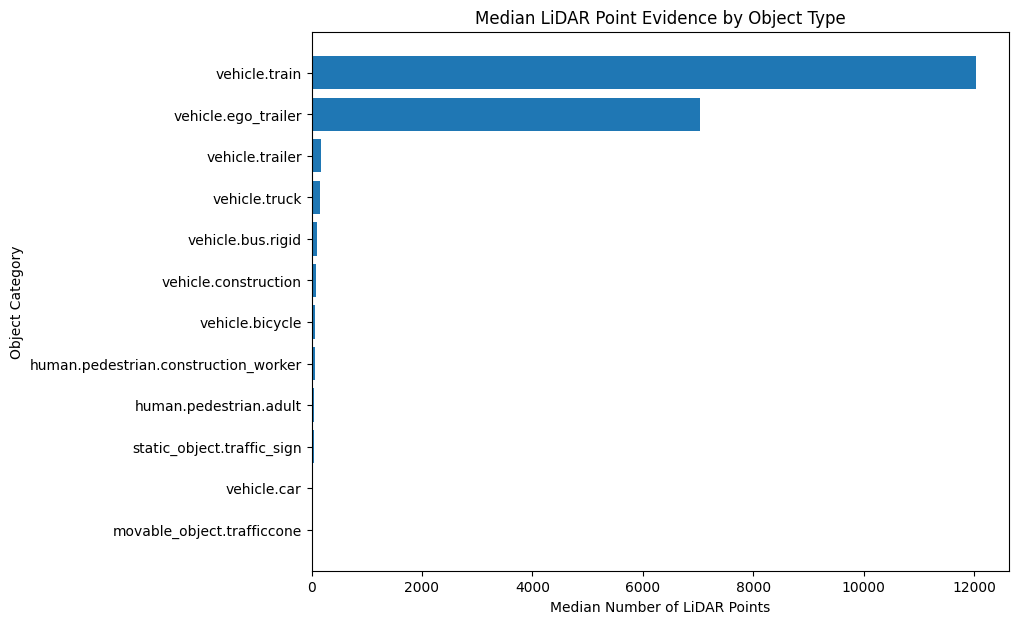

In [62]:
lidar_type_summary = object_type_summary.sort_values(
    "median_lidar_pts"
)

plt.figure(figsize=(9, 7))

plt.barh(
    lidar_type_summary["category"],
    lidar_type_summary["median_lidar_pts"]
)

plt.xlabel("Median Number of LiDAR Points")
plt.ylabel("Object Category")
plt.title("Median LiDAR Point Evidence by Object Type")

plt.show()

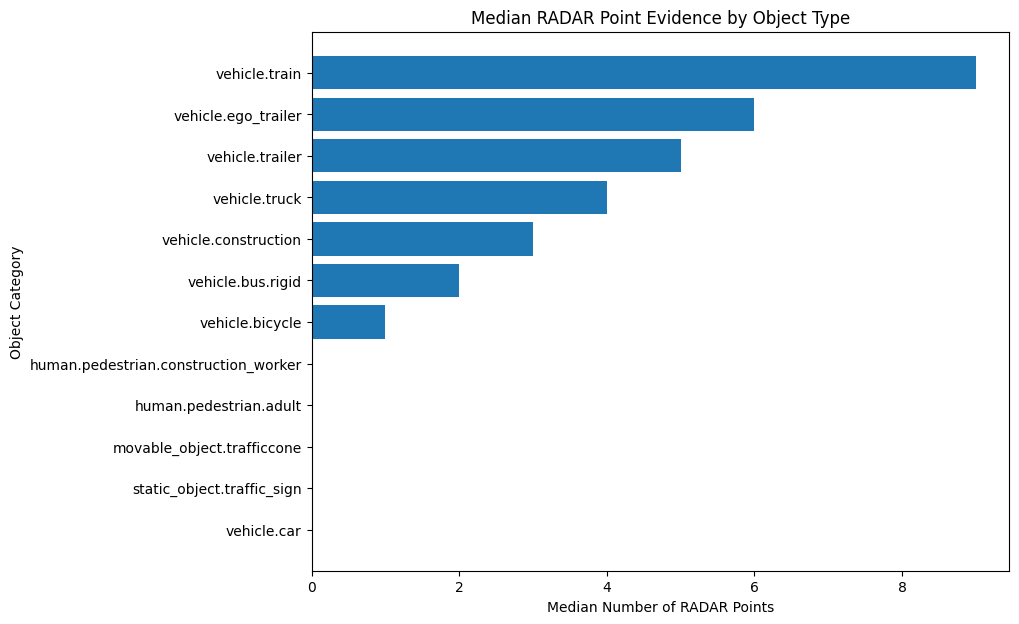

In [63]:
radar_type_summary = object_type_summary.sort_values(
    "median_radar_pts"
)

plt.figure(figsize=(9, 7))

plt.barh(
    radar_type_summary["category"],
    radar_type_summary["median_radar_pts"]
)

plt.xlabel("Median Number of RADAR Points")
plt.ylabel("Object Category")
plt.title("Median RADAR Point Evidence by Object Type")

plt.show()

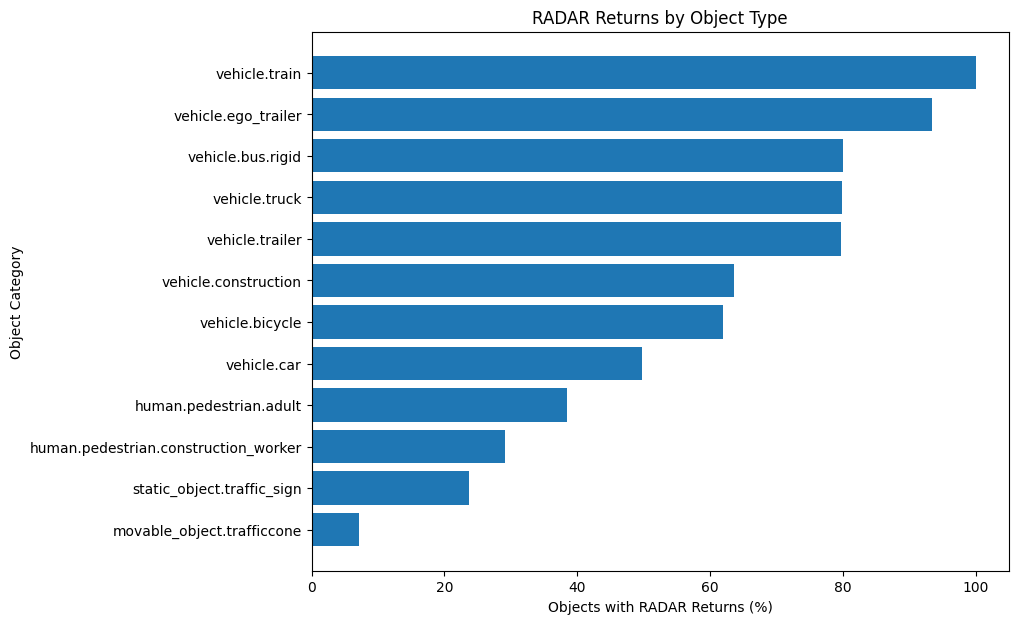

In [64]:
radar_return_summary = object_type_summary.sort_values(
    "radar_return_rate"
)

plt.figure(figsize=(9, 7))

plt.barh(
    radar_return_summary["category"],
    radar_return_summary["radar_return_rate"] * 100
)

plt.xlabel("Objects with RADAR Returns (%)")
plt.ylabel("Object Category")
plt.title("RADAR Returns by Object Type")

plt.show()

#### Findings

Object type is strongly associated with the amount of sensor evidence available.

For LiDAR, larger vehicle categories generally contain more associated points, while smaller objects such as pedestrians, traffic signs, and traffic cones contain fewer points. This follows the pattern observed in the object-size analysis, suggesting that physical size contributes substantially to the differences between categories.

RADAR shows an even clearer variation across object types. Heavy vehicles such as trucks, trailers, buses, and trains generally have higher median RADAR point counts and a larger proportion of annotations containing RADAR returns. In contrast, cars have a median RADAR point count of 0 despite being the most common object category, while pedestrian categories and traffic cones show relatively low RADAR return proportions.

These results suggest that RADAR evidence is more consistently available for large vehicle-type objects than for smaller road users and roadside objects. However, the differences should not be attributed to object type alone, since categories also differ substantially in physical size and typical distance from the ego vehicle.

The `vehicle.ego_trailer` category should also be interpreted cautiously because it represents the recording vehicle's own trailer and is therefore not directly comparable with normal external road objects.

Overall, the results show that sensor evidence varies substantially across object categories, motivating later combined analysis that considers object type together with range and object size.

### 5.5 Visibility

**Research question:** How does object visibility affect the amount of RADAR and LiDAR evidence associated with labelled objects?

truckScenes provides four visibility levels based on the proportion of the object visible in the panoramic camera view. The analysis compares sensor evidence across these visibility levels to examine whether reduced visibility is associated with fewer LiDAR or RADAR returns.

In [74]:
visibility_counts = (
    df["visibility_level"]
    .value_counts()
    .sort_index()
)

visibility_counts

visibility_level
1     8346
2     2176
3     2034
4    13194
Name: count, dtype: int64

In [76]:
visibility_summary = (
    df.groupby("visibility_level")
    .agg(
        n_objects=("annotation_token", "count"),
        median_distance=("distance_3d", "median"),
        median_volume=("object_volume", "median"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

visibility_summary

,visibility_level,n_objects,median_distance,median_volume,median_lidar_pts,median_radar_pts,radar_return_rate
0,1,8346,100.196376,11.544400,9.0,0.0,0.272586
1,2,2176,72.834148,12.757825,29.0,0.0,0.471967
2,3,2034,65.062033,12.116017,38.0,1.0,0.505408
3,4,13194,42.355708,11.427813,101.0,1.0,0.585872


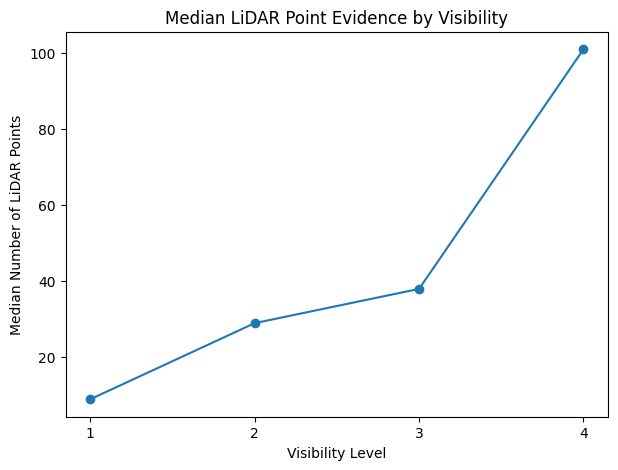

In [77]:
plt.figure(figsize=(7, 5))

plt.plot(
    visibility_summary["visibility_level"],
    visibility_summary["median_lidar_pts"],
    marker="o"
)

plt.xlabel("Visibility Level")
plt.ylabel("Median Number of LiDAR Points")
plt.title("Median LiDAR Point Evidence by Visibility")

plt.xticks([1, 2, 3, 4])
plt.show()

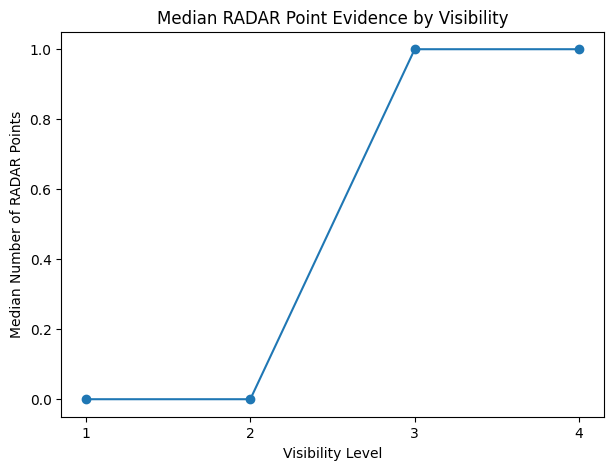

In [78]:
plt.figure(figsize=(7, 5))

plt.plot(
    visibility_summary["visibility_level"],
    visibility_summary["median_radar_pts"],
    marker="o"
)

plt.xlabel("Visibility Level")
plt.ylabel("Median Number of RADAR Points")
plt.title("Median RADAR Point Evidence by Visibility")

plt.xticks([1, 2, 3, 4])
plt.show()

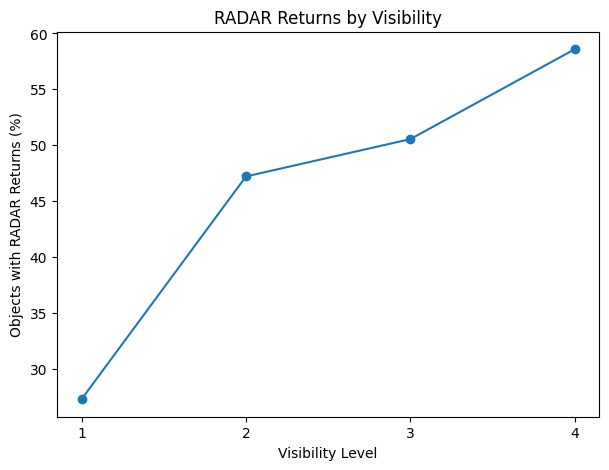

In [79]:
plt.figure(figsize=(7, 5))

plt.plot(
    visibility_summary["visibility_level"],
    visibility_summary["radar_return_rate"] * 100,
    marker="o"
)

plt.xlabel("Visibility Level")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Visibility")

plt.xticks([1, 2, 3, 4])
plt.show()

#### Findings

Sensor evidence increases consistently with object visibility. Median LiDAR point count rises from 9 points at visibility level 1 to 101 points at visibility level 4. RADAR shows a similar pattern: the median point count increases from 0 at lower visibility levels to 1 at higher visibility levels, while the proportion of annotations containing RADAR returns increases from approximately 27% at visibility level 1 to 59% at level 4.

However, visibility is strongly associated with object range in this dataset. Objects at visibility level 1 have a median distance of approximately 100 m, compared with about 42 m for visibility level 4. Since the range analysis showed that sensor evidence decreases substantially with distance, the observed visibility effect cannot be attributed to occlusion alone.

Object size remains relatively similar across visibility levels, suggesting that size is less likely to explain the observed differences.

Overall, lower-visibility objects contain substantially less LiDAR and RADAR evidence, but a combined analysis controlling for distance is required to determine how much of this relationship is specifically associated with visibility.

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25750 entries, 0 to 25749
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   scene_token               25750 non-null  str     
 1   sample_token              25750 non-null  str     
 2   annotation_token          25750 non-null  str     
 3   instance_token            25750 non-null  str     
 4   visibility_token          25750 non-null  str     
 5   weather_annotation_token  25750 non-null  str     
 6   timestamp                 25750 non-null  int64   
 7   category                  25750 non-null  str     
 8   attribute                 24612 non-null  str     
 9   visibility_level          25750 non-null  int64   
 10  visibility_description    25750 non-null  str     
 11  size_1                    25750 non-null  float64 
 12  size_2                    25750 non-null  float64 
 13  size_3                    25750 non-null  float64 
 14  o

### 5.6 Weather Conditions

**Research question:** How does RADAR and LiDAR evidence vary under different weather conditions?

Weather information is defined at the scene level. Therefore, sensor measurements are first aggregated within each scene before weather conditions are compared. This avoids treating thousands of objects from the same scene as independent weather observations.

The analysis focuses primarily on categorical weather conditions and quantitative precipitation.

In [81]:
weather_scene_counts = (
    df[["scene_token", "weather"]]
    .drop_duplicates()
    ["weather"]
    .value_counts()
)

weather_scene_counts

weather
clear       4
overcast    3
rain        2
snow        1
Name: count, dtype: int64

In [82]:
weather_measurements = (
    df[
        [
            "scene_token",
            "weather",
            "precipitation",
            "wind_speed",
            "wind_direction",
            "temperature"
        ]
    ]
    .drop_duplicates()
    .sort_values("scene_token")
)

weather_measurements

,scene_token,weather,precipitation,wind_speed,wind_direction,temperature
0,044c648ac12345f1aedf33c9f91cdc5a,clear,0.00,1.70,177.0,295.5
21781,073e6bb18188424ea9981e3845df54a6,clear,0.00,0.53,285.0,282.8
1285,37355c547904491481e47accc094d567,clear,0.00,0.83,210.0,289.7
12320,38d4ba33fce94499be34f32d245113ed,clear,0.00,0.10,231.0,282.2
2574,81f0a41d0a7a44e0ae8f8ea0ade95fdf,overcast,0.00,4.80,264.0,281.4
11683,9fb76bae00124c85aaf4d6d0e4dbf194,rain,0.04,2.43,200.0,285.5
18806,b13b6eb5c4bf4479a631372af53baf28,rain,4.27,1.53,217.0,281.9
6782,b71e2b6ba3fa4279b36bfd4b9720251e,overcast,0.00,0.14,263.0,285.6
16241,d0b02e67e97a435192bf43f7bb0f902c,snow,1.59,0.46,358.0,273.6
8314,fb0a3d4e84c74b07ba0997891ed12f0b,overcast,0.00,0.96,266.0,286.7


In [84]:
scene_weather_summary = (
    df.groupby(
        [
            "scene_token",
            "weather",
            "precipitation",
            "wind_speed",
            "temperature"
        ],
        dropna=False
    )
    .agg(
        n_objects=("annotation_token", "count"),
        median_distance=("distance_3d", "median"),
        median_volume=("object_volume", "median"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

scene_weather_summary

,scene_token,weather,precipitation,wind_speed,temperature,n_objects,median_distance,median_volume,median_lidar_pts,median_radar_pts,radar_return_rate
0,044c648ac12345f1aedf33c9f91cdc5a,clear,0.00,1.70,295.5,1285,20.600151,43.791298,608.0,4.0,0.862257
1,073e6bb18188424ea9981e3845df54a6,clear,0.00,0.53,282.8,3969,62.012632,10.757046,43.0,0.0,0.496599
2,37355c547904491481e47accc094d567,clear,0.00,0.83,289.7,1289,93.963841,12.728098,38.0,0.0,0.401862
3,38d4ba33fce94499be34f32d245113ed,clear,0.00,0.10,282.2,3921,59.002765,9.921175,35.0,0.0,0.442999
4,81f0a41d0a7a44e0ae8f8ea0ade95fdf,overcast,0.00,4.80,281.4,4208,66.970485,7.663842,22.0,0.0,0.308698
5,9fb76bae00124c85aaf4d6d0e4dbf194,rain,0.04,2.43,285.5,637,37.693744,94.234633,223.0,1.0,0.598116
6,b13b6eb5c4bf4479a631372af53baf28,rain,4.27,1.53,281.9,2975,78.138123,13.181762,25.0,0.0,0.497143
7,b71e2b6ba3fa4279b36bfd4b9720251e,overcast,0.00,0.14,285.6,1532,100.188895,18.618306,38.0,0.0,0.494778
8,d0b02e67e97a435192bf43f7bb0f902c,snow,1.59,0.46,273.6,2565,43.040969,12.941858,55.0,1.0,0.584405
9,fb0a3d4e84c74b07ba0997891ed12f0b,overcast,0.00,0.96,286.7,3369,96.990844,12.067510,21.0,0.0,0.388839


#### A. Weather category

In [85]:
weather_summary = (
    scene_weather_summary.groupby("weather")
    .agg(
        n_scenes=("scene_token", "count"),
        median_precipitation=("precipitation", "median"),
        median_lidar_pts=("median_lidar_pts", "median"),
        median_radar_pts=("median_radar_pts", "median"),
        median_radar_return_rate=("radar_return_rate", "median")
    )
    .reset_index()
)

weather_summary

,weather,n_scenes,median_precipitation,median_lidar_pts,median_radar_pts,median_radar_return_rate
0,clear,4,0.000,40.5,0.0,0.469799
1,overcast,3,0.000,22.0,0.0,0.388839
2,rain,2,2.155,124.0,0.5,0.547630
3,snow,1,1.590,55.0,1.0,0.584405


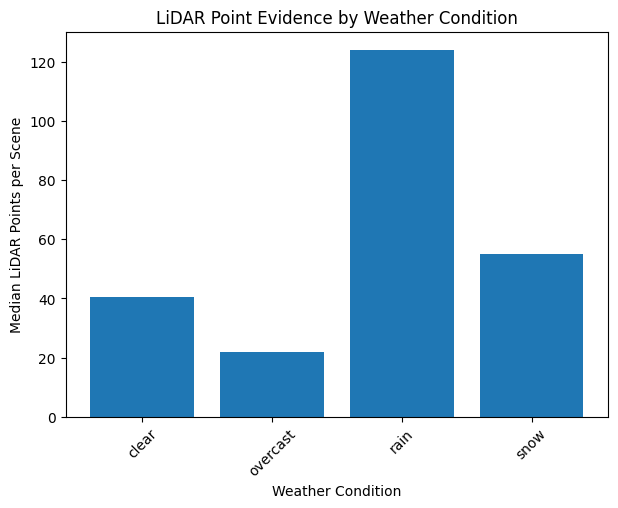

In [86]:
plt.figure(figsize=(7, 5))

plt.bar(
    weather_summary["weather"],
    weather_summary["median_lidar_pts"]
)

plt.xlabel("Weather Condition")
plt.ylabel("Median LiDAR Points per Scene")
plt.title("LiDAR Point Evidence by Weather Condition")
plt.xticks(rotation=45)

plt.show()

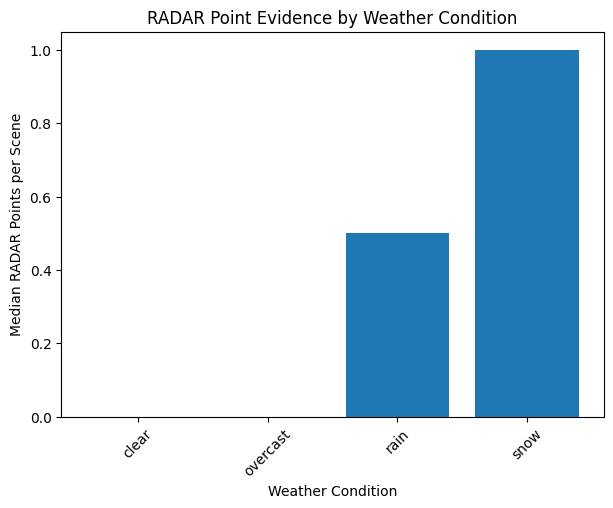

In [87]:
plt.figure(figsize=(7, 5))

plt.bar(
    weather_summary["weather"],
    weather_summary["median_radar_pts"]
)

plt.xlabel("Weather Condition")
plt.ylabel("Median RADAR Points per Scene")
plt.title("RADAR Point Evidence by Weather Condition")
plt.xticks(rotation=45)

plt.show()

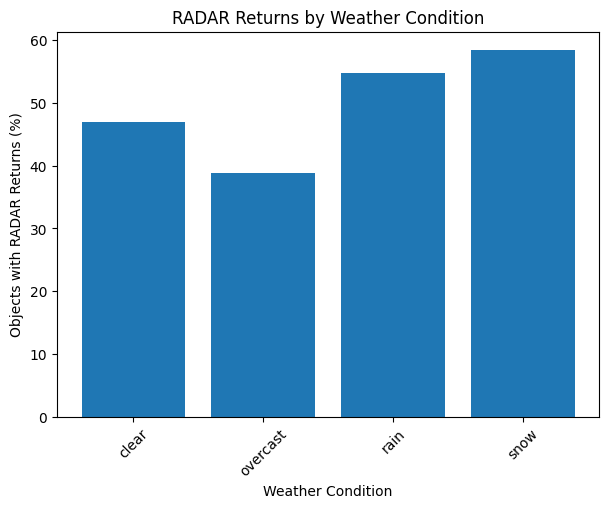

In [88]:
plt.figure(figsize=(7, 5))

plt.bar(
    weather_summary["weather"],
    weather_summary["median_radar_return_rate"] * 100
)

plt.xlabel("Weather Condition")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Weather Condition")
plt.xticks(rotation=45)

plt.show()

#### B. Precipitation


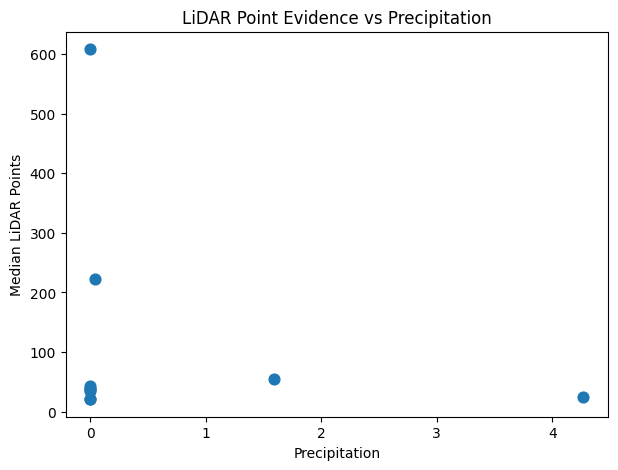

In [89]:
plt.figure(figsize=(7, 5))

plt.scatter(
    scene_weather_summary["precipitation"],
    scene_weather_summary["median_lidar_pts"],
    s=60
)

plt.xlabel("Precipitation")
plt.ylabel("Median LiDAR Points")
plt.title("LiDAR Point Evidence vs Precipitation")

plt.show()

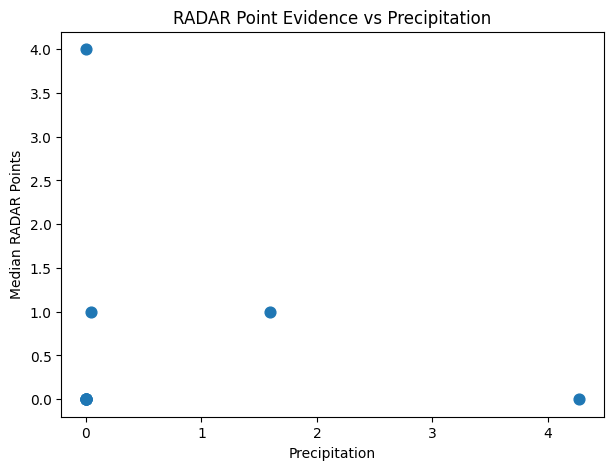

In [90]:
plt.figure(figsize=(7, 5))

plt.scatter(
    scene_weather_summary["precipitation"],
    scene_weather_summary["median_radar_pts"],
    s=60
)

plt.xlabel("Precipitation")
plt.ylabel("Median RADAR Points")
plt.title("RADAR Point Evidence vs Precipitation")

plt.show()

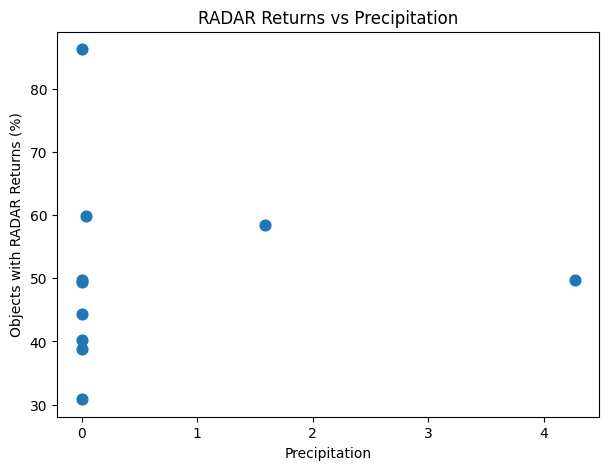

In [91]:
plt.figure(figsize=(7, 5))

plt.scatter(
    scene_weather_summary["precipitation"],
    scene_weather_summary["radar_return_rate"] * 100,
    s=60
)

plt.xlabel("Precipitation")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns vs Precipitation")

plt.show()

#### Findings

Sensor evidence varies across the available weather conditions, but the observed differences should be interpreted cautiously because only 10 scenes are available and the weather categories are unbalanced.

Rain and snow scenes show relatively high sensor evidence in the raw comparison, while overcast scenes generally contain lower LiDAR and RADAR evidence. However, the scenes also differ substantially in object distance, object size, and object composition. For example, one rainy scene contains considerably larger and closer objects, which is likely to contribute to its high point counts.

The quantitative precipitation analysis does not show a clear monotonic relationship between precipitation level and either LiDAR or RADAR evidence. Higher precipitation does not consistently correspond to lower sensor point counts or lower RADAR return proportions.

Therefore, the current mini dataset does not provide sufficient evidence to isolate a direct weather effect on sensor performance. Weather-related differences observed here are likely mixed with scene composition, object size, and range, and should be revisited in the combined analysis.

### 5.7 Scene / Environmental Conditions

**Research question:** How does sensor evidence vary across different driving environments and broader scene conditions?

Several scene-level conditions are available in truckScenes, including area type, daytime, season, lighting, road structure, and construction conditions. Because these variables are defined at the scene level, sensor measurements are aggregated by scene before comparison.

The mini dataset contains sufficient variation in area type and season for exploratory comparison. Other conditions such as lighting, road structure, and construction are highly unbalanced and are therefore not analysed in detail.

In [92]:
scene_conditions = (
    df[
        [
            "scene_token","area","daytime","season",
            "lighting","structure","construction"
        ]
    ]
    .drop_duplicates()
)

for condition in [
    "area",
    "daytime",
    "season",
    "lighting",
    "structure",
    "construction"
]:
    print(f"\n{condition}")
    print(scene_conditions[condition].value_counts())


area
area
highway     4
city        4
terminal    2
Name: count, dtype: int64

daytime
daytime
noon       7
morning    2
evening    1
Name: count, dtype: int64

season
season
autumn    4
winter    3
summer    3
Name: count, dtype: int64

lighting
lighting
illuminated       7
dark              1
twilight          1
other_lighting    1
Name: count, dtype: int64

structure
structure
regular     8
overpass    1
bridge      1
Name: count, dtype: int64

construction
construction
unchanged    9
roadworks    1
Name: count, dtype: int64


In [93]:
scene_environment_summary = (
    df.groupby(
        [
            "scene_token",
            "area",
            "daytime",
            "season",
            "lighting",
            "structure",
            "construction"
        ],
        dropna=False
    )
    .agg(
        n_objects=("annotation_token", "count"),
        median_distance=("distance_3d", "median"),
        median_volume=("object_volume", "median"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

scene_environment_summary

,scene_token,area,daytime,season,lighting,structure,construction,n_objects,median_distance,median_volume,median_lidar_pts,median_radar_pts,radar_return_rate
0,044c648ac12345f1aedf33c9f91cdc5a,terminal,noon,autumn,illuminated,regular,unchanged,1285,20.600151,43.791298,608.0,4.0,0.862257
1,073e6bb18188424ea9981e3845df54a6,city,noon,winter,other_lighting,regular,unchanged,3969,62.012632,10.757046,43.0,0.0,0.496599
2,37355c547904491481e47accc094d567,highway,evening,autumn,dark,overpass,unchanged,1289,93.963841,12.728098,38.0,0.0,0.401862
3,38d4ba33fce94499be34f32d245113ed,city,noon,winter,twilight,regular,unchanged,3921,59.002765,9.921175,35.0,0.0,0.442999
4,81f0a41d0a7a44e0ae8f8ea0ade95fdf,city,noon,winter,illuminated,bridge,unchanged,4208,66.970485,7.663842,22.0,0.0,0.308698
5,9fb76bae00124c85aaf4d6d0e4dbf194,terminal,morning,summer,illuminated,regular,unchanged,637,37.693744,94.234633,223.0,1.0,0.598116
6,b13b6eb5c4bf4479a631372af53baf28,highway,noon,autumn,illuminated,regular,unchanged,2975,78.138123,13.181762,25.0,0.0,0.497143
7,b71e2b6ba3fa4279b36bfd4b9720251e,highway,noon,summer,illuminated,regular,unchanged,1532,100.188895,18.618306,38.0,0.0,0.494778
8,d0b02e67e97a435192bf43f7bb0f902c,city,noon,autumn,illuminated,regular,unchanged,2565,43.040969,12.941858,55.0,1.0,0.584405
9,fb0a3d4e84c74b07ba0997891ed12f0b,highway,morning,summer,illuminated,regular,roadworks,3369,96.990844,12.067510,21.0,0.0,0.388839


#### A. Area

In [94]:
area_summary = (
    scene_environment_summary.groupby("area")
    .agg(
        n_scenes=("scene_token", "count"),
        median_distance=("median_distance", "median"),
        median_volume=("median_volume", "median"),
        median_lidar_pts=("median_lidar_pts", "median"),
        median_radar_pts=("median_radar_pts", "median"),
        median_radar_return_rate=("radar_return_rate", "median")
    )
    .reset_index()
)

area_summary

,area,n_scenes,median_distance,median_volume,median_lidar_pts,median_radar_pts,median_radar_return_rate
0,city,4,60.507699,10.339110,39.0,0.0,0.469799
1,highway,4,95.477343,12.954930,31.5,0.0,0.448320
2,terminal,2,29.146948,69.012965,415.5,2.5,0.730186


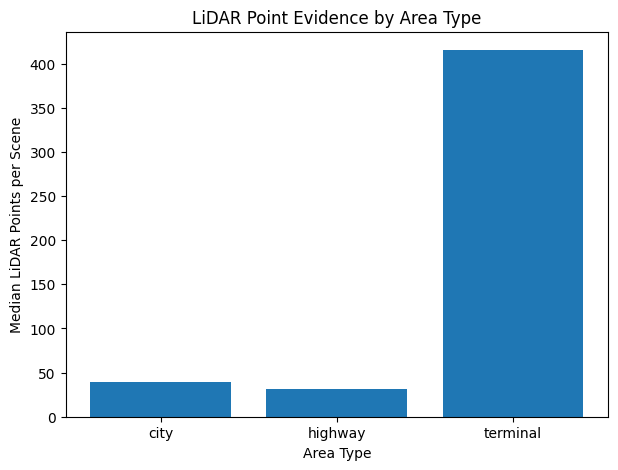

In [95]:
plt.figure(figsize=(7, 5))

plt.bar(
    area_summary["area"],
    area_summary["median_lidar_pts"]
)

plt.xlabel("Area Type")
plt.ylabel("Median LiDAR Points per Scene")
plt.title("LiDAR Point Evidence by Area Type")

plt.show()

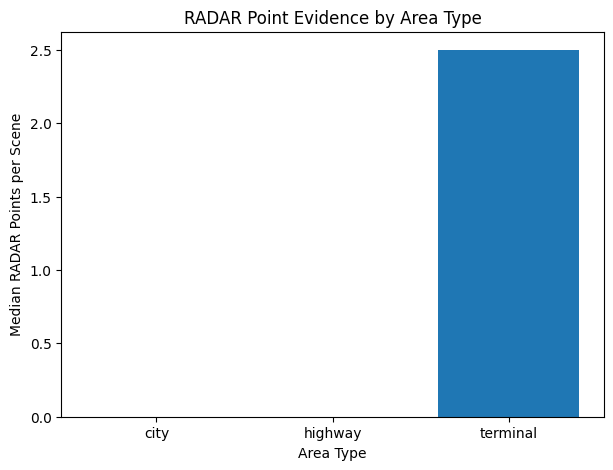

In [96]:
plt.figure(figsize=(7, 5))

plt.bar(
    area_summary["area"],
    area_summary["median_radar_pts"]
)

plt.xlabel("Area Type")
plt.ylabel("Median RADAR Points per Scene")
plt.title("RADAR Point Evidence by Area Type")

plt.show()

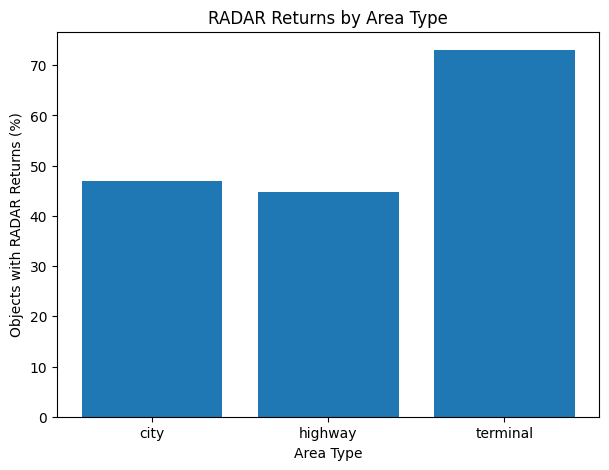

In [97]:
plt.figure(figsize=(7, 5))

plt.bar(
    area_summary["area"],
    area_summary["median_radar_return_rate"] * 100
)

plt.xlabel("Area Type")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Area Type")

plt.show()

#### B.Season

In [99]:
season_summary = (
    scene_environment_summary.groupby("season")
    .agg(
        n_scenes=("scene_token", "count"),
        median_distance=("median_distance", "median"),
        median_volume=("median_volume", "median"),
        median_lidar_pts=("median_lidar_pts", "median"),
        median_radar_pts=("median_radar_pts", "median"),
        median_radar_return_rate=("radar_return_rate", "median")
    )
    .reset_index()
)

season_summary

,season,n_scenes,median_distance,median_volume,median_lidar_pts,median_radar_pts,median_radar_return_rate
0,autumn,4,60.589546,13.061810,46.5,0.5,0.540774
1,summer,3,96.990844,18.618306,38.0,0.0,0.494778
2,winter,3,62.012632,9.921175,35.0,0.0,0.442999


#### Findings

Sensor evidence differs across scene environments, with terminal scenes showing substantially higher LiDAR and RADAR evidence than city and highway scenes. Terminal scenes have a median LiDAR point count of approximately 416 points, a median RADAR point count of 2.5, and a RADAR-return proportion of about 73%.

However, terminal scenes also contain much closer and substantially larger objects. Their median object distance is approximately 29 m and median object volume is around 69, compared with considerably smaller and more distant objects in city and highway scenes. Therefore, the stronger sensor evidence in terminal environments cannot be attributed to area type alone.

City and highway scenes show more similar sensor behaviour. City scenes contain slightly more LiDAR evidence and a slightly higher RADAR-return proportion, but highway objects are observed at considerably longer ranges, which likely contributes to the difference.

Seasonal differences are relatively small. Autumn scenes show somewhat higher sensor evidence, while summer scenes contain the most distant objects on average. This suggests that the apparent seasonal pattern may primarily reflect differences in scene composition and range rather than a direct seasonal effect.

Overall, scene-level conditions show noticeable differences in sensor evidence, but the mini dataset is too small and confounded to isolate the effect of environment alone.

### 5.8 RADAR Relative Velocity Information

**Research question:** What additional motion information does RADAR provide for labelled objects?

Unlike the previous analyses, relative velocity is a measurement provided directly by individual RADAR returns rather than an environmental or object condition. Each RADAR point in truckScenes contains three relative-velocity components (`vrel_x`, `vrel_y`, and `vrel_z`).

The analysis first associates RADAR points with labelled 3D object boxes and then summarises the relative-velocity measurements available for each object.

In [107]:
ann_lookup = {
    ann["token"]: ann
    for ann in trucksc.sample_annotation
}

velocity_rows = []

for sample in tqdm(trucksc.sample, desc="Extracting RADAR velocity"):

    ann_tokens = [
        token
        for token in sample["anns"]
        if ann_lookup[token]["num_radar_pts"] > 0
    ]

    if not ann_tokens:
        continue

    sample_values = {
        token: {
            "relative_speed": [],
            "radial_velocity": [],
            "abs_radial_velocity": [],
            "rcs": []
        }
        for token in ann_tokens
    }

    radar_channels = [
        channel
        for channel in sample["data"]
        if channel.startswith("RADAR_")
    ]

    for channel in radar_channels:

        sample_data_token = sample["data"][channel]

        data_path, boxes, _ = trucksc.get_sample_data(
            sample_data_token,
            selected_anntokens=ann_tokens
        )

        radar_pc = RadarPointCloud.from_file(data_path)

        positions = radar_pc.points[:3, :]
        velocities = radar_pc.points[3:6, :]
        rcs = radar_pc.points[6, :]

        relative_speed = np.linalg.norm(
            velocities,
            axis=0
        )

        point_range = np.linalg.norm(
            positions,
            axis=0
        )

        radial_velocity = np.full(
            point_range.shape,
            np.nan,
            dtype=float
        )

        valid_range = point_range > 0

        radial_velocity[valid_range] = (
            np.sum(
                positions[:, valid_range]
                * velocities[:, valid_range],
                axis=0
            )
            / point_range[valid_range]
        )

        for box in boxes:

            mask = points_in_box(
                box,
                positions
            )

            if not mask.any():
                continue

            token = box.token

            sample_values[token]["relative_speed"].extend(
                relative_speed[mask].tolist()
            )

            sample_values[token]["radial_velocity"].extend(
                radial_velocity[mask].tolist()
            )

            sample_values[token]["abs_radial_velocity"].extend(
                np.abs(radial_velocity[mask]).tolist()
            )

            sample_values[token]["rcs"].extend(
                rcs[mask].tolist()
            )

    for token, values in sample_values.items():

        if not values["relative_speed"]:
            continue

        velocity_rows.append({
            "annotation_token": token,
            "radar_velocity_point_count": len(
                values["relative_speed"]
            ),
            "median_relative_speed": np.median(
                values["relative_speed"]
            ),
            "median_radial_velocity": np.nanmedian(
                values["radial_velocity"]
            ),
            "median_abs_radial_velocity": np.nanmedian(
                values["abs_radial_velocity"]
            ),
            "median_rcs": np.median(
                values["rcs"]
            )
        })

velocity_object_df = pd.DataFrame(velocity_rows)

velocity_object_df.head()

Extracting RADAR velocity:   0%|          | 0/400 [00:00<?, ?it/s]

,annotation_token,radar_velocity_point_count,median_relative_speed,median_radial_velocity,median_abs_radial_velocity,median_rcs
0,50873dd5195b47bc9544ac2821e054e0,2,2.440476,-2.440476,2.440476,-11.5
1,7611254877134bf5a2f8c2d1ac182a9f,2,2.439266,-2.439266,2.439266,3.0
2,c4a9dfe7426b43cbaacc425db160137d,8,2.434960,-2.434960,2.434960,-1.5
3,533fcd99c7e3422dacb8a5f46818c4c4,3,2.472129,-2.472129,2.472129,3.0
4,74afcd8b8b044ed2b572e523b8376186,4,2.005022,-2.005022,2.005022,-2.0


In [108]:
velocity_check = (
    df[
        [
            "annotation_token",
            "num_radar_pts"
        ]
    ]
    .merge(
        velocity_object_df[
            [
                "annotation_token",
                "radar_velocity_point_count"
            ]
        ],
        on="annotation_token",
        how="left"
    )
)

velocity_check["radar_velocity_point_count"] = (
    velocity_check["radar_velocity_point_count"]
    .fillna(0)
    .astype(int)
)

velocity_check["count_match"] = (
    velocity_check["num_radar_pts"]
    == velocity_check["radar_velocity_point_count"]
)

velocity_check["count_match"].value_counts()

count_match
True     25504
False      246
Name: count, dtype: int64

In [109]:
velocity_check["count_difference"] = (
    velocity_check["radar_velocity_point_count"]
    - velocity_check["num_radar_pts"]
)

velocity_check["count_difference"].value_counts().sort_index()

count_difference
-4        1
-3        3
-2       16
-1      141
 0    25504
 1       71
 2       11
 3        2
 4        1
Name: count, dtype: int64

In [113]:
df = df.merge(
    velocity_object_df,
    on="annotation_token",
    how="left"
)

df["radar_velocity_point_count"] = (
    df["radar_velocity_point_count"]
    .fillna(0)
    .astype(int)
)

df["velocity_count_match"] = (
    df["num_radar_pts"]
    == df["radar_velocity_point_count"]
)

In [114]:
velocity_df = df[
    (df["num_radar_pts"] > 0)
    & (df["velocity_count_match"])
].copy()

#### A.Relative Velocity by Motion State

In [115]:
velocity_df.shape

(11814, 49)

In [116]:
velocity_df["motion_state"].value_counts()

motion_state
moving        6031
stationary    3868
unknown       1915
Name: count, dtype: int64

In [117]:
velocity_motion_df = velocity_df[
    velocity_df["motion_state"].isin(["moving", "stationary"])
].copy()

In [118]:
velocity_motion_summary = (
    velocity_motion_df.groupby("motion_state")
    .agg(
        n_objects=("annotation_token", "count"),
        median_distance=("distance_3d", "median"),
        median_relative_speed=("median_relative_speed", "median"),
        median_radial_velocity=("median_radial_velocity", "median"),
        median_abs_radial_velocity=("median_abs_radial_velocity", "median")
    )
    .reset_index()
)

velocity_motion_summary

,motion_state,n_objects,median_distance,median_relative_speed,median_radial_velocity,median_abs_radial_velocity
0,moving,6031,50.889151,4.217803,-0.009513,4.217803
1,stationary,3868,39.800314,2.865549,-0.517895,2.865549


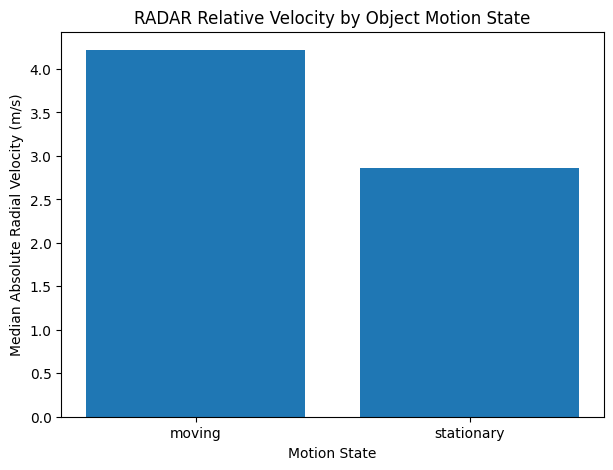

In [119]:
plt.figure(figsize=(7, 5))

plt.bar(
    velocity_motion_summary["motion_state"],
    velocity_motion_summary["median_abs_radial_velocity"]
)

plt.xlabel("Motion State")
plt.ylabel("Median Absolute Radial Velocity (m/s)")
plt.title("RADAR Relative Velocity by Object Motion State")

plt.show()

#### B.Velocity information availability with distance

In [120]:
velocity_distance_summary = (
    df.groupby("distance_band", observed=True)
    .agg(
        n_objects=("annotation_token", "count"),
        objects_with_radar=("radar_detected", "sum")
    )
    .reset_index()
)

In [121]:
validated_velocity_counts = (
    velocity_df.groupby("distance_band", observed=True)
    .size()
    .reset_index(name="objects_with_velocity")
)

velocity_distance_summary = velocity_distance_summary.merge(
    validated_velocity_counts,
    on="distance_band",
    how="left"
)

velocity_distance_summary["objects_with_velocity"] = (
    velocity_distance_summary["objects_with_velocity"]
    .fillna(0)
    .astype(int)
)

velocity_distance_summary["velocity_availability"] = (
    velocity_distance_summary["objects_with_velocity"]
    / velocity_distance_summary["n_objects"]
)

velocity_distance_summary

,distance_band,n_objects,objects_with_radar,objects_with_velocity,velocity_availability
0,"[0, 25)",4009,3109,3015,0.752058
1,"[25, 50)",6443,3810,3744,0.581096
2,"[50, 75)",4948,2253,2216,0.447858
3,"[75, 100)",3544,1313,1291,0.364278
4,"[100, 125)",2644,736,724,0.273828
5,"[125, 150)",1784,476,467,0.261771
6,"[150, 175)",1133,250,245,0.216240
7,"[175, 200)",807,112,111,0.137546
8,"[200, 225)",431,1,1,0.002320
9,"[225, 250)",7,0,0,0.000000


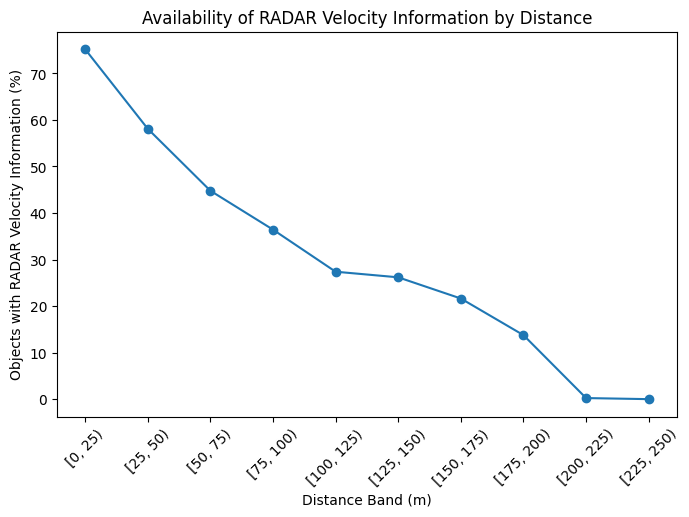

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(
    velocity_distance_summary["distance_band"].astype(str),
    velocity_distance_summary["velocity_availability"] * 100,
    marker="o"
)

plt.xlabel("Distance Band (m)")
plt.ylabel("Objects with RADAR Velocity Information (%)")
plt.title("Availability of RADAR Velocity Information by Distance")
plt.xticks(rotation=45)

plt.show()

#### Findings

RADAR provides measurable relative-motion information for a substantial subset of annotated objects. Objects labelled as moving have a higher median absolute radial velocity (approximately 4.22 m/s) than stationary objects (approximately 2.87 m/s), indicating that RADAR measurements capture meaningful differences in relative motion.

However, stationary objects can still exhibit non-zero relative velocity because RADAR measures motion relative to the ego vehicle rather than absolute object speed. Therefore, RADAR relative velocity should not be interpreted directly as an object's own velocity.

The availability of RADAR velocity information also decreases strongly with distance. Approximately 75% of objects within 25 m contain validated RADAR velocity information, falling to about 36% at 75–100 m and below 14% beyond 175 m.

This reduction primarily reflects the decreasing availability of RADAR returns at longer ranges. When a RADAR return is present, velocity information is generally available as part of that return. Therefore, the main limitation at long range is the availability of RADAR evidence rather than a separate loss of velocity measurement capability.

### 5.9 Combined Effects

#### 5.9.1 Distance × Visibility

The earlier visibility analysis showed that low-visibility objects were also typically farther from the ego vehicle. Therefore, distance and visibility are examined together to determine whether differences in sensor evidence remain when objects are compared within similar distance ranges.

In [123]:
distance_visibility_counts = (
    df.groupby(
        ["distance_band", "visibility_level"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

distance_visibility_counts

visibility_level,1,2,3,4
distance_band,,,,
"[0, 25)",549,151,187,3122
"[25, 50)",797,448,461,4737
"[50, 75)",1395,535,538,2480
"[75, 100)",1419,491,372,1262
"[100, 125)",1431,276,217,720
"[125, 150)",1124,114,123,423
"[150, 175)",733,79,79,242
"[175, 200)",592,50,45,120
"[200, 225)",302,31,12,86


In [124]:
distance_visibility_summary = (
    df.groupby(
        ["distance_band", "visibility_level"],
        observed=True
    )
    .agg(
        n_objects=("annotation_token", "count"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

distance_visibility_summary

,distance_band,visibility_level,n_objects,median_lidar_pts,median_radar_pts,radar_return_rate
0,"[0, 25)",1,549,4736.0,4.0,0.795993
1,"[0, 25)",2,151,260.0,2.0,0.741722
2,"[0, 25)",3,187,3382.0,6.0,0.866310
3,"[0, 25)",4,3122,687.5,2.0,0.768097
4,"[25, 50)",1,797,45.0,0.0,0.466750
5,"[25, 50)",2,448,70.5,1.0,0.593750
6,"[25, 50)",3,461,101.0,1.0,0.600868
7,"[25, 50)",4,4737,129.0,1.0,0.611146
8,"[50, 75)",1,1395,16.0,0.0,0.318280
9,"[50, 75)",2,535,34.0,0.0,0.497196


In [125]:
distance_visibility_plot = distance_visibility_summary[
    distance_visibility_summary["n_objects"] >= 30
].copy()

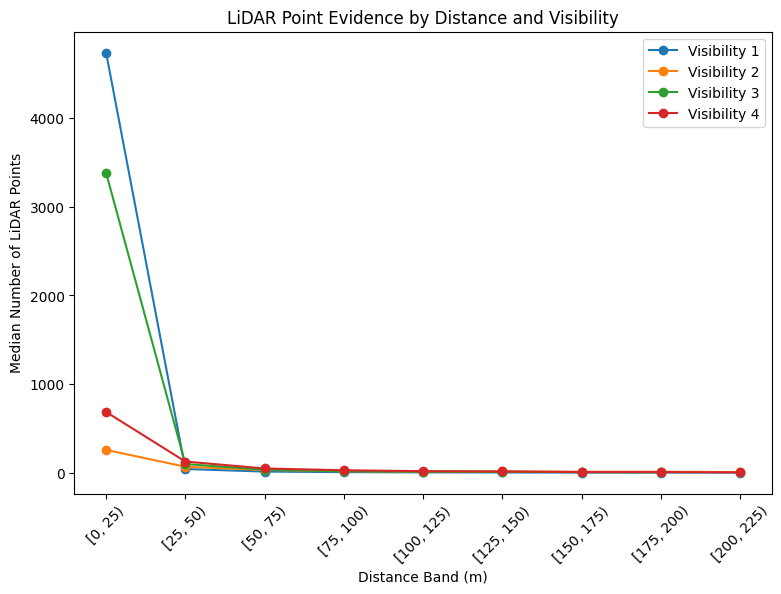

In [126]:
plt.figure(figsize=(9, 6))

for level in sorted(
    distance_visibility_plot["visibility_level"].unique()
):
    subset = distance_visibility_plot[
        distance_visibility_plot["visibility_level"] == level
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_lidar_pts"],
        marker="o",
        label=f"Visibility {level}"
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of LiDAR Points")
plt.title("LiDAR Point Evidence by Distance and Visibility")
plt.xticks(rotation=45)
plt.legend()

plt.show()

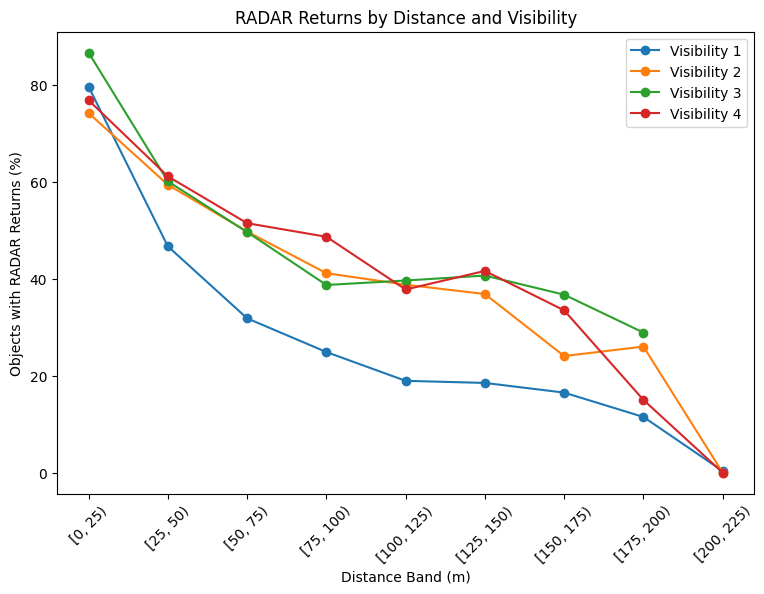

In [127]:
plt.figure(figsize=(9, 6))

for level in sorted(
    distance_visibility_plot["visibility_level"].unique()
):
    subset = distance_visibility_plot[
        distance_visibility_plot["visibility_level"] == level
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["radar_return_rate"] * 100,
        marker="o",
        label=f"Visibility {level}"
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Distance and Visibility")
plt.xticks(rotation=45)
plt.legend()

plt.show()

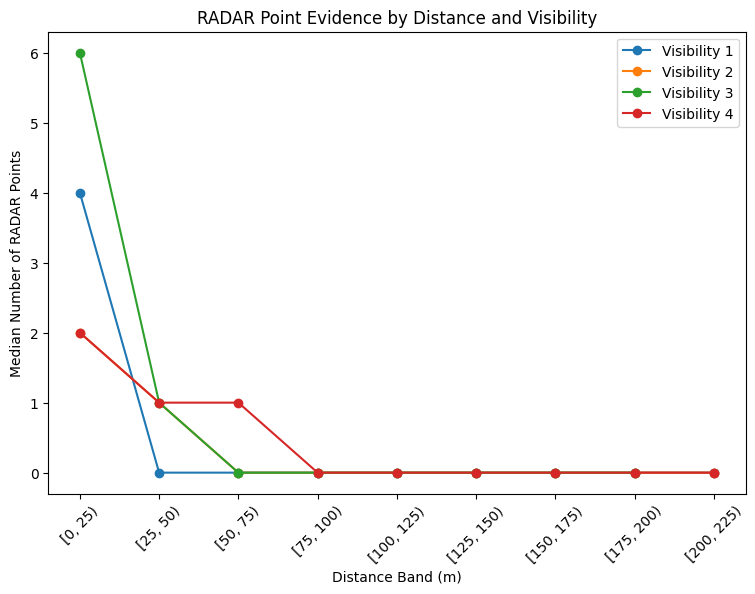

In [128]:
plt.figure(figsize=(9, 6))

for level in sorted(
    distance_visibility_plot["visibility_level"].unique()
):
    subset = distance_visibility_plot[
        distance_visibility_plot["visibility_level"] == level
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_radar_pts"],
        marker="o",
        label=f"Visibility {level}"
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of RADAR Points")
plt.title("RADAR Point Evidence by Distance and Visibility")
plt.xticks(rotation=45)
plt.legend()

plt.show()

#### Findings

Combining distance and visibility shows that the lower sensor evidence observed for poorly visible objects cannot be explained by distance alone.

Within comparable distance bands, objects with the lowest visibility level generally have lower RADAR return rates than objects with moderate or high visibility. For example, at 50–75 m, approximately 32% of Visibility 1 objects contain RADAR returns, compared with about 50% for Visibility Levels 2–4. A similar difference remains across several longer-distance bands.

The separation is strongest between Visibility Level 1 and the remaining levels, while Levels 2–4 often show relatively similar RADAR return rates. This suggests that severe object occlusion has a stronger association with RADAR return availability than smaller differences among moderately or highly visible objects.

LiDAR evidence shows a broadly similar pattern from approximately 25 m onward, with more visible objects generally receiving more LiDAR points within the same distance range. The 0–25 m band behaves differently, likely because close-range object geometry and object composition have a strong influence on point density.

Overall, distance remains an important factor for both sensors, but object visibility appears to provide additional information about sensor evidence beyond distance alone.

#### 5.9.2 Distance × Object Type

The object-type analysis showed substantial differences in sensor evidence between categories. However, different object types also occur at different typical distances from the ego vehicle.

Distance and object type are therefore examined together to determine whether differences in sensor evidence remain when object categories are compared within similar distance ranges.

In [129]:
main_categories = [
    "vehicle.car",
    "static_object.traffic_sign",
    "vehicle.truck",
    "vehicle.trailer",
    "human.pedestrian.adult",
    "movable_object.trafficcone"
]

distance_type_df = df[
    df["category"].isin(main_categories)
].copy()

In [131]:
distance_type_summary = (
    distance_type_df.groupby(
        ["distance_band", "category"],
        observed=True
    )
    .agg(
        n_objects=("annotation_token", "count"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

distance_type_summary

,distance_band,category,n_objects,median_lidar_pts,median_radar_pts,radar_return_rate
0,"[0, 25)",human.pedestrian.adult,204,183.5,1.0,0.681373
1,"[0, 25)",movable_object.trafficcone,102,60.5,0.0,0.382353
2,"[0, 25)",static_object.traffic_sign,1091,206.0,0.0,0.466544
3,"[0, 25)",vehicle.car,1247,1146.0,4.0,0.913392
4,"[0, 25)",vehicle.trailer,387,3596.0,14.0,0.981912
5,"[0, 25)",vehicle.truck,347,4447.0,14.0,0.991354
6,"[25, 50)",human.pedestrian.adult,469,54.0,0.0,0.413646
7,"[25, 50)",movable_object.trafficcone,152,35.0,0.0,0.105263
8,"[25, 50)",static_object.traffic_sign,1926,57.0,0.0,0.262721
9,"[25, 50)",vehicle.car,2376,176.0,2.0,0.783670


In [132]:
distance_type_plot = distance_type_summary[
    distance_type_summary["n_objects"] >= 30
].copy()

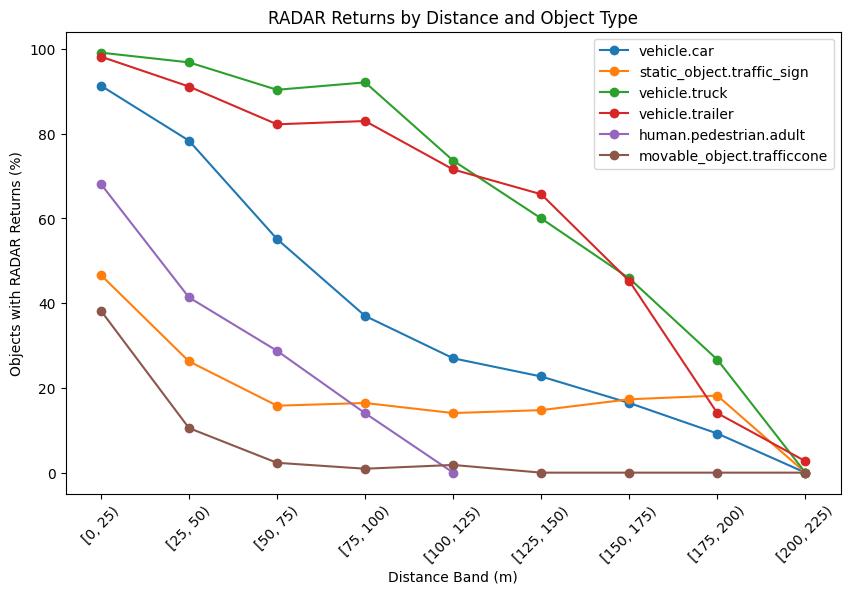

In [133]:
plt.figure(figsize=(10, 6))

for category in main_categories:
    subset = distance_type_plot[
        distance_type_plot["category"] == category
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["radar_return_rate"] * 100,
        marker="o",
        label=category
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Distance and Object Type")
plt.xticks(rotation=45)
plt.legend()

plt.show()

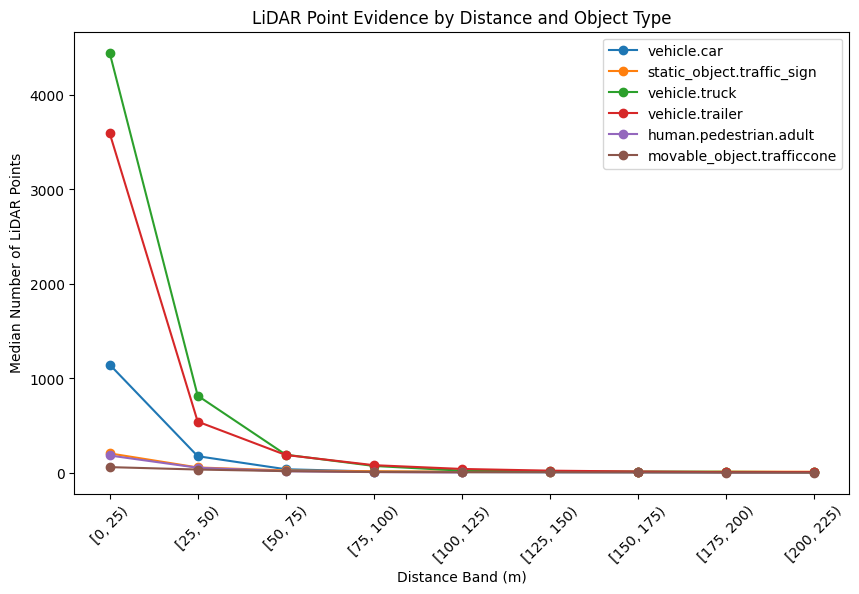

In [134]:
plt.figure(figsize=(10, 6))

for category in main_categories:
    subset = distance_type_plot[
        distance_type_plot["category"] == category
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_lidar_pts"],
        marker="o",
        label=category
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of LiDAR Points")
plt.title("LiDAR Point Evidence by Distance and Object Type")
plt.xticks(rotation=45)
plt.legend()

plt.show()

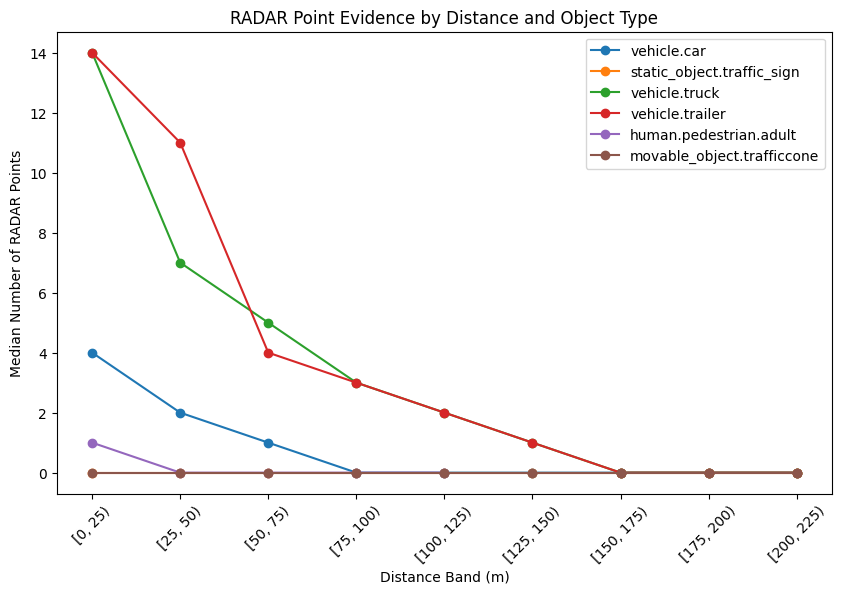

In [135]:
plt.figure(figsize=(10, 6))

for category in main_categories:
    subset = distance_type_plot[
        distance_type_plot["category"] == category
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_radar_pts"],
        marker="o",
        label=category
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of RADAR Points")
plt.title("RADAR Point Evidence by Distance and Object Type")
plt.xticks(rotation=45)
plt.legend()

plt.show()

#### Findings

The combined distance and object-type analysis shows that differences between object categories remain substantial even when objects are compared within similar distance ranges.

Large vehicle categories, particularly trucks and trailers, consistently produce stronger sensor evidence than smaller objects. For RADAR, trucks and trailers maintain substantially higher return rates across most distance bands. For example, at 50–75 m, approximately 90% of trucks and 82% of trailers contain RADAR returns, compared with 55% of cars, 29% of adult pedestrians, 16% of traffic signs and only 2% of traffic cones.

The median number of RADAR points shows a similar pattern at short and medium distances, with trucks and trailers generally producing more RADAR points when returns are present. At longer distances, median RADAR point counts frequently fall to zero because fewer than half of the annotated objects receive a RADAR return, making return rate the more informative metric.

LiDAR evidence also decreases strongly with distance for all object categories. However, large objects such as trucks and trailers retain considerably more LiDAR points than smaller categories within the same distance bands.

Overall, distance is a major factor affecting sensor evidence, but it does not fully explain the differences between object categories. Object-related characteristics such as size, geometry and reflective properties are also likely to influence the amount and availability of LiDAR and RADAR evidence.

#### 5.9.3 Distance × Motion State

The earlier motion-state analysis showed differences in sensor evidence between moving and stationary objects. However, moving objects were also observed at greater median distances.

Distance and motion state are therefore analysed together to determine whether differences in sensor evidence remain when moving and stationary objects are compared within similar distance ranges.

In [136]:
distance_motion_df = df[
    df["motion_state"].isin(["moving", "stationary"])
].copy()

In [137]:
distance_motion_counts = (
    distance_motion_df.groupby(
        ["distance_band", "motion_state"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

distance_motion_counts

motion_state,moving,stationary
distance_band,,
"[0, 25)",1481,1137
"[25, 50)",2282,1907
"[50, 75)",1905,1450
"[75, 100)",1547,979
"[100, 125)",1381,557
"[125, 150)",1073,271
"[150, 175)",734,83
"[175, 200)",580,11
"[200, 225)",314,6


In [138]:
distance_motion_summary = (
    distance_motion_df.groupby(
        ["distance_band", "motion_state"],
        observed=True
    )
    .agg(
        n_objects=("annotation_token", "count"),
        median_lidar_pts=("num_lidar_pts", "median"),
        median_radar_pts=("num_radar_pts", "median"),
        radar_return_rate=("radar_detected", "mean")
    )
    .reset_index()
)

distance_motion_summary

,distance_band,motion_state,n_objects,median_lidar_pts,median_radar_pts,radar_return_rate
0,"[0, 25)",moving,1481,2034.0,5.0,0.903444
1,"[0, 25)",stationary,1137,1565.0,5.0,0.927001
2,"[25, 50)",moving,2282,167.5,2.0,0.739702
3,"[25, 50)",stationary,1907,176.0,2.0,0.763503
4,"[50, 75)",moving,1905,53.0,1.0,0.655118
5,"[50, 75)",stationary,1450,33.0,1.0,0.528966
6,"[75, 100)",moving,1547,20.0,0.0,0.484809
7,"[75, 100)",stationary,979,14.0,0.0,0.425945
8,"[100, 125)",moving,1381,11.0,0.0,0.350471
9,"[100, 125)",stationary,557,8.0,0.0,0.294434


In [139]:
distance_motion_plot = distance_motion_summary[
    distance_motion_summary["n_objects"] >= 30
].copy()

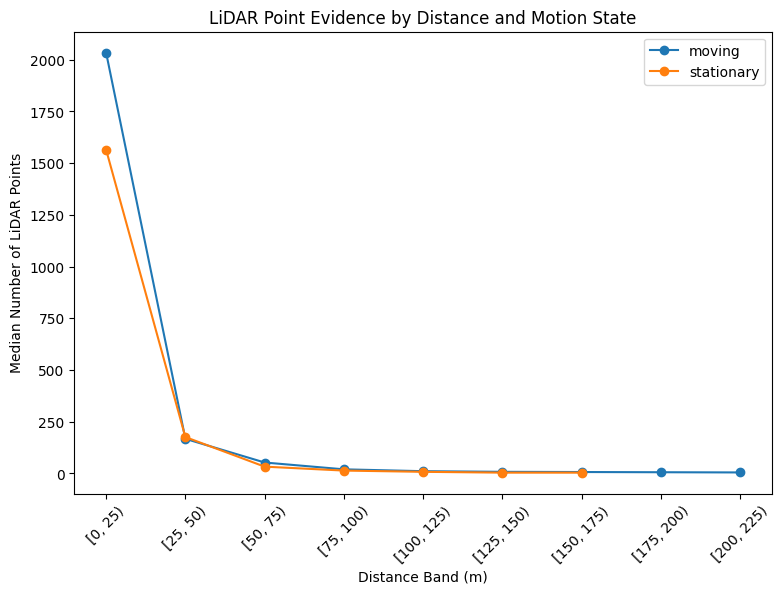

In [140]:
plt.figure(figsize=(9, 6))

for state in ["moving", "stationary"]:
    subset = distance_motion_plot[
        distance_motion_plot["motion_state"] == state
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_lidar_pts"],
        marker="o",
        label=state
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of LiDAR Points")
plt.title("LiDAR Point Evidence by Distance and Motion State")
plt.xticks(rotation=45)
plt.legend()

plt.show()

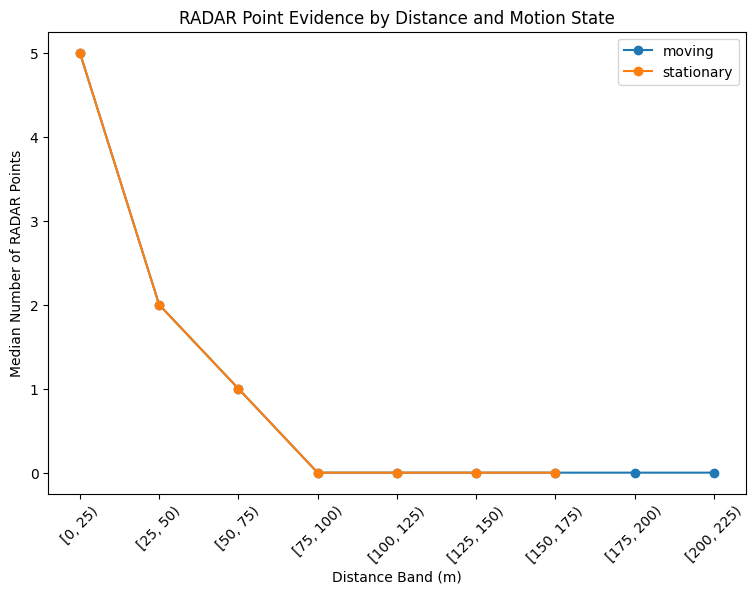

In [143]:
plt.figure(figsize=(9, 6))

for state in ["moving","stationary"]:
    subset = distance_motion_plot[
        distance_motion_plot["motion_state"] == state
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_radar_pts"],
        marker="o",
        label=state
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of RADAR Points")
plt.title("RADAR Point Evidence by Distance and Motion State")
plt.xticks(rotation=45)
plt.legend()

plt.show()

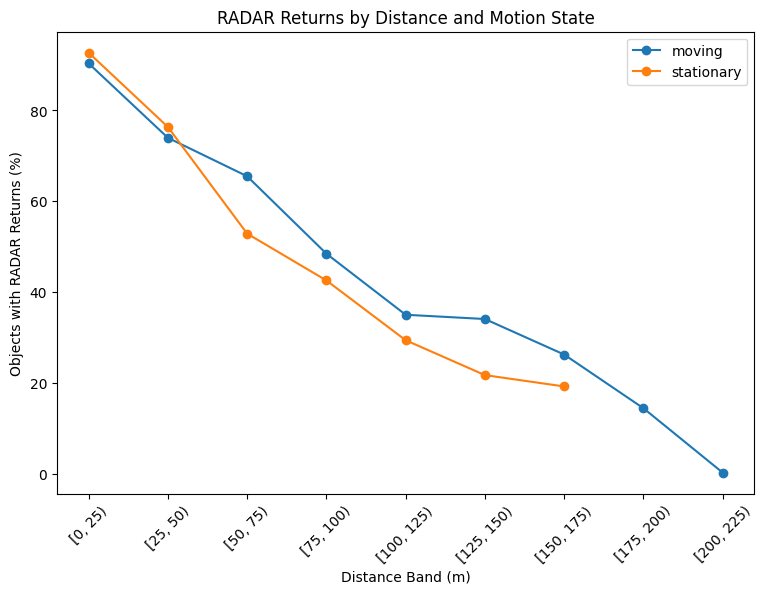

In [144]:
plt.figure(figsize=(9, 6))

for state in ["moving", "stationary"]:
    subset = distance_motion_plot[
        distance_motion_plot["motion_state"] == state
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["radar_return_rate"] * 100,
        marker="o",
        label=state
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Objects with RADAR Returns (%)")
plt.title("RADAR Returns by Distance and Motion State")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [145]:
distance_motion_detected = distance_motion_df[
    distance_motion_df["radar_detected"]
].copy()

distance_motion_radar_summary = (
    distance_motion_detected.groupby(
        ["distance_band", "motion_state"],
        observed=True
    )
    .agg(
        n_detected=("annotation_token", "count"),
        median_radar_pts_detected=("num_radar_pts", "median")
    )
    .reset_index()
)

distance_motion_radar_summary

,distance_band,motion_state,n_detected,median_radar_pts_detected
0,"[0, 25)",moving,1338,6.0
1,"[0, 25)",stationary,1054,6.0
2,"[25, 50)",moving,1688,3.0
3,"[25, 50)",stationary,1456,3.0
4,"[50, 75)",moving,1248,2.0
5,"[50, 75)",stationary,767,2.0
6,"[75, 100)",moving,750,2.0
7,"[75, 100)",stationary,417,1.0
8,"[100, 125)",moving,484,2.0
9,"[100, 125)",stationary,164,1.0


In [146]:
distance_motion_radar_plot = distance_motion_radar_summary[
    distance_motion_radar_summary["n_detected"] >= 30
].copy()

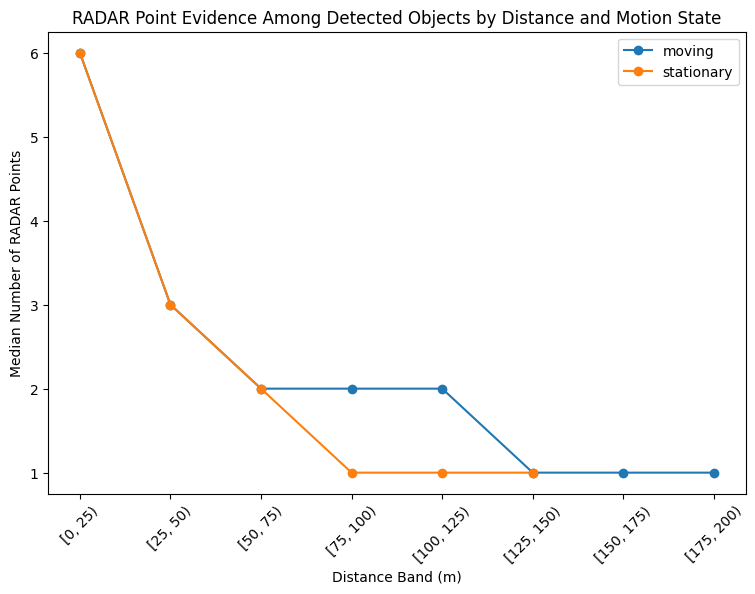

In [147]:
plt.figure(figsize=(9, 6))

for state in ["moving", "stationary"]:
    subset = distance_motion_radar_plot[
        distance_motion_radar_plot["motion_state"] == state
    ]

    plt.plot(
        subset["distance_band"].astype(str),
        subset["median_radar_pts_detected"],
        marker="o",
        label=state
    )

plt.xlabel("Distance Band (m)")
plt.ylabel("Median Number of RADAR Points")
plt.title("RADAR Point Evidence Among Detected Objects by Distance and Motion State")
plt.xticks(rotation=45)
plt.legend()

plt.show()

#### Findings

Distance remains the dominant factor affecting RADAR point evidence. Among objects with at least one RADAR return, the median number of points decreases from 6 at 0–25 m to 3 at 25–50 m and approximately 1–2 points beyond 75 m.

Moving and stationary objects receive similar numbers of RADAR points at short distances. Between approximately 75 and 125 m, moving objects retain slightly more RADAR point evidence than stationary objects. Combined with the RADAR return-rate results, this suggests that object motion has a stronger relationship with the availability of a RADAR return than with the number of points once a return is present.

Long-range stationary-object results are not compared because relatively few detected stationary objects remain in these distance bands.